In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [34]:
df.shape

(1040200, 35)

In [35]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [36]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month

monthly_df = (
    df.groupby(['store_name', 'year', 'month'])['sales_amount_realistic']
    .sum()
    .reset_index()
)

monthly_df['date'] = pd.to_datetime(
    monthly_df[['year', 'month']].assign(day=1)
)

monthly_df = monthly_df.sort_values(['store_name', 'date'])

In [37]:
monthly_df['store_id'] = monthly_df['store_name'].astype('category').cat.codes

In [38]:
monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df['month'] / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df['month'] / 12)

In [39]:
for lag in [1,3,6,12]:
    monthly_df[f'lag_{lag}'] = (
        monthly_df.groupby('store_id')['sales_amount_realistic']
        .shift(lag)
    )

In [40]:
monthly_df['rolling_mean_3'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(3).mean().reset_index(0, drop=True)
)

monthly_df['rolling_mean_6'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(6).mean().reset_index(0, drop=True)
)

In [41]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [42]:
# =========================
# Feature Engineering
# =========================

monthly_df = (
    df.groupby(["store_name", "store_id", "year", "month"], as_index=False)
    .agg({
        "sales_amount_realistic": "sum",
        "gdp_per_capita": "mean",
        "inflation_rate": "mean",
        "exchange_rate": "mean",
        "internet_usage_pct": "mean",
        "season_factor": "mean",
        "promo_flag": "max"
    })
)

monthly_df["date"] = pd.to_datetime(
    monthly_df["year"].astype(str) + "-" +
    monthly_df["month"].astype(str) + "-01"
)

monthly_df = monthly_df.sort_values(["store_id", "date"]).reset_index(drop=True)

monthly_df["store_id_encoded"] = (
    monthly_df["store_id"].astype("category").cat.codes
)

monthly_df["month_sin"] = np.sin(2 * np.pi * monthly_df["month"] / 12)
monthly_df["month_cos"] = np.cos(2 * np.pi * monthly_df["month"] / 12)

for lag in [1, 2, 3, 6, 9, 12]:
    monthly_df[f"lag_{lag}"] = (
        monthly_df.groupby("store_id")["sales_amount_realistic"].shift(lag)
    )

monthly_df["rolling_mean_3"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

monthly_df["rolling_mean_6"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(6).mean())
)

monthly_df["rolling_mean_12"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(12).mean())
)

monthly_df["rolling_std_3"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(3).std())
)

monthly_df["rolling_std_6"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(6).std())
)

monthly_df["rolling_std_12"] = (
    monthly_df.groupby("store_id")["sales_amount_realistic"]
    .transform(lambda x: x.shift(1).rolling(12).std())
)

monthly_df["yoy_growth"] = (
    (monthly_df["lag_1"] - monthly_df["lag_12"]) / monthly_df["lag_12"]
)

monthly_df["sales_momentum"] = monthly_df["lag_1"] - monthly_df["lag_3"]

monthly_avg = (
    monthly_df.groupby(["store_id", "month"])["lag_1"].transform("mean")
)

monthly_df["season_strength"] = monthly_df["lag_1"] / monthly_avg
monthly_df["seasonal_diff"] = monthly_df["lag_1"] - monthly_df["lag_12"]

monthly_df["trend_3_12"] = (
    monthly_df["rolling_mean_3"] / monthly_df["rolling_mean_12"]
)

# prevent extreme overestimation
monthly_df["yoy_growth"] = monthly_df["yoy_growth"].clip(-0.3, 0.3)
monthly_df["trend_3_12"] = monthly_df["trend_3_12"].clip(0.8, 1.2)

monthly_df["gdp_growth"] = (
    monthly_df.groupby("store_id")["gdp_per_capita"].pct_change()
)

monthly_df["inflation_change"] = (
    monthly_df.groupby("store_id")["inflation_rate"].pct_change()
)

monthly_df["exchange_change"] = (
    monthly_df.groupby("store_id")["exchange_rate"].pct_change()
)

monthly_df["internet_growth"] = (
    monthly_df.groupby("store_id")["internet_usage_pct"].pct_change()
)

for col in ["gdp_growth", "inflation_change", "exchange_change", "internet_growth"]:
    monthly_df[col] = monthly_df.groupby("store_id")[col].shift(1)

monthly_df["promo_flag_lag1"] = (
    monthly_df.groupby("store_id")["promo_flag"].shift(1)
)

monthly_df["gdp_sales_effect"] = monthly_df["gdp_growth"] * monthly_df["lag_1"]
monthly_df["inflation_sales_effect"] = monthly_df["inflation_change"] * monthly_df["lag_1"]
monthly_df["exchange_sales_effect"] = monthly_df["exchange_change"] * monthly_df["lag_1"]
monthly_df["promo_season_effect"] = monthly_df["promo_flag_lag1"] * monthly_df["season_factor"]

monthly_df["last_month_vs_year_avg"] = (
    monthly_df["lag_1"] / monthly_df["rolling_mean_12"]
).clip(0.7, 1.3)

monthly_df = monthly_df.replace([np.inf, -np.inf], np.nan).fillna(0)

feature_cols = [
    "store_id_encoded",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_9", "lag_12",
    "rolling_mean_3", "rolling_mean_6", "rolling_mean_12",
    "rolling_std_3", "rolling_std_6", "rolling_std_12",
    "yoy_growth", "sales_momentum", "season_strength",
    "seasonal_diff", "trend_3_12",
    "gdp_growth", "inflation_change", "exchange_change", "internet_growth",
    "season_factor", "promo_flag_lag1",
    "gdp_sales_effect", "inflation_sales_effect", "exchange_sales_effect",
    "promo_season_effect", "last_month_vs_year_avg"
]

print(monthly_df[feature_cols].head())


   store_id_encoded  month_sin     month_cos         lag_1         lag_2  \
0                 0   0.500000  8.660254e-01  0.000000e+00  0.000000e+00   
1                 0   0.866025  5.000000e-01  1.469554e+06  0.000000e+00   
2                 0   1.000000  6.123234e-17  1.767766e+06  1.469554e+06   
3                 0   0.866025 -5.000000e-01  1.763047e+06  1.767766e+06   
4                 0   0.500000 -8.660254e-01  1.809825e+06  1.763047e+06   

          lag_3  lag_6  lag_9  lag_12  rolling_mean_3  ...  exchange_change  \
0  0.000000e+00    0.0    0.0     0.0    0.000000e+00  ...              0.0   
1  0.000000e+00    0.0    0.0     0.0    0.000000e+00  ...              0.0   
2  0.000000e+00    0.0    0.0     0.0    0.000000e+00  ...              0.0   
3  1.469554e+06    0.0    0.0     0.0    1.666789e+06  ...              0.0   
4  1.767766e+06    0.0    0.0     0.0    1.780213e+06  ...              0.0   

   internet_growth  season_factor  promo_flag  promo_season_effect  

In [43]:
def create_sequences_multi(X, y, input_window=12, output_window=12):
    X_seq, y_seq = [], []

    for i in range(len(X) - input_window - output_window + 1):
        X_seq.append(X[i:i+input_window])
        y_seq.append(y[i+input_window:i+input_window+output_window])

    return np.array(X_seq), np.array(y_seq)

In [44]:
X_all = []
y_all = []
store_ids_per_sample = []

for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[monthly_df['store_id'] == store_id]
    
    X = store_data[feature_cols].values
    y = store_data['sales_amount_realistic'].values
    
    X_seq, y_seq = create_sequences_multi(X, y)
    
    X_all.append(X_seq)
    y_all.append(y_seq)
    
    store_ids_per_sample.extend([store_id] * len(X_seq))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
store_ids_per_sample = np.array(store_ids_per_sample)

In [45]:
split = int(len(X_all) * 0.8)

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

store_ids_train = store_ids_per_sample[:split]
store_ids_test = store_ids_per_sample[split:]

In [46]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [47]:
model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(12, len(feature_cols))),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(12)   # predict 12 months
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

d:\anaconda\envs\Apple\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 12, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 12, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,100 (2.09 MB)

 Trainable params: 549,100 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.4722 - mae: 0.5121 - val_loss: 0.2721 - val_mae: 0.3777
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2700 - mae: 0.3830 - val_loss: 0.2207 - val_mae: 0.3341
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2322 - mae: 0.3592 - val_loss: 0.1999 - val_mae: 0.3295
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2103 - mae: 0.3427 - val_loss: 0.1818 - val_mae: 0.3175
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2036 - mae: 0.3391 - val_loss: 0.1796 - val_mae: 0.3258
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1886 - mae: 0.3245 - val_loss: 0.1560 - val_mae: 0.2961
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1737 - mae: 0.3128 - val_loss: 0.1531 - val_mae: 0.2876
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1656 - mae: 0.3058 - val_loss: 0.1377 - val_mae: 0.2735
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1571 -

In [49]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
r2 = r2_score(y_true.flatten(), y_pred.flatten())

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
MAE: 166545.41572369973
RMSE: 215159.27803900727
R2: 0.9055934127204832


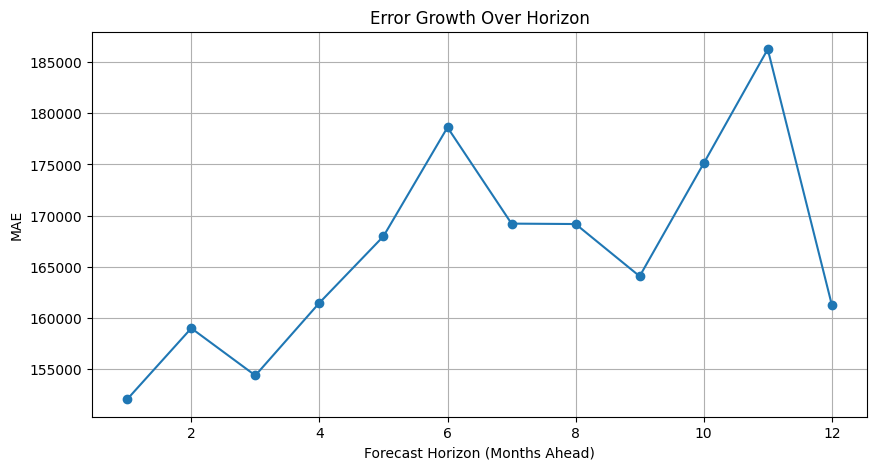

In [50]:
horizon_mae = []

for i in range(12):
    mae_i = np.mean(np.abs(y_true[:, i] - y_pred[:, i]))
    horizon_mae.append(mae_i)

plt.figure(figsize=(10,5))
plt.plot(range(1,13), horizon_mae, marker='o')
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("MAE")
plt.title("Error Growth Over Horizon")
plt.grid(True)
plt.show()

In [51]:
store_errors = []

for store_id in np.unique(store_ids_test):
    
    mask = store_ids_test == store_id
    
    true_store = y_true[mask]
    pred_store = y_pred[mask]
    
    mae_store = np.mean(np.abs(true_store - pred_store))
    
    store_errors.append((store_id, mae_store))

store_error_df = pd.DataFrame(
    store_errors,
    columns=["store_id", "MAE"]
).sort_values("MAE", ascending=False)

store_error_df.head()

,store_id,MAE
6,ST-7,246033.637448
2,ST-66,226002.286266
13,ST-8,214215.627569
3,ST-67,195104.193783
10,ST-73,193588.961886


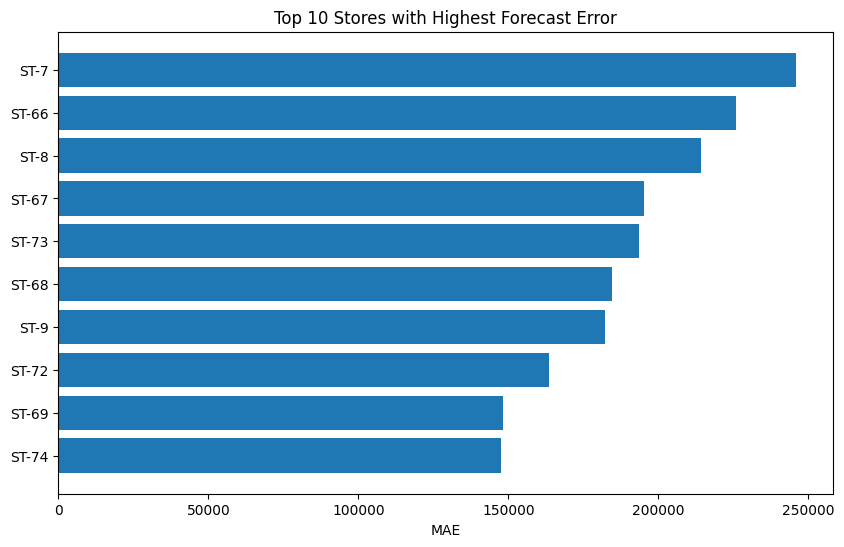

In [52]:
top_worst = store_error_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_worst['store_id'].astype(str), top_worst['MAE'])
plt.xlabel("MAE")
plt.title("Top 10 Stores with Highest Forecast Error")
plt.gca().invert_yaxis()
plt.show()

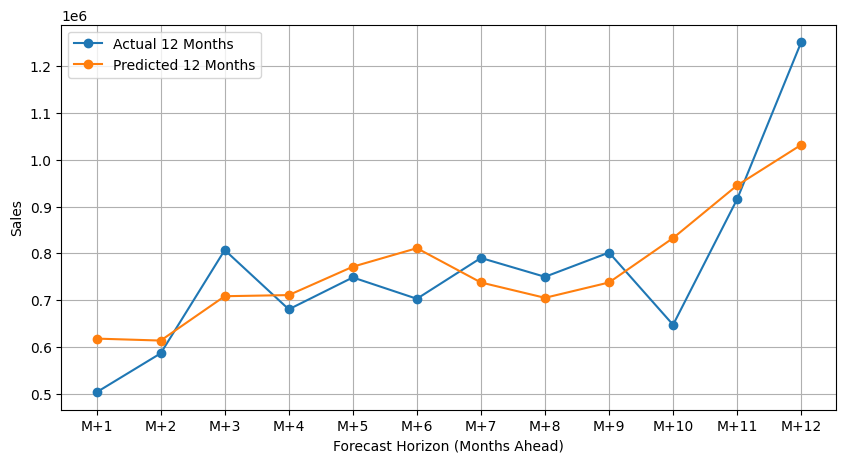

In [53]:
months = np.arange(1, 13)
months = [f"M+{i}" for i in range(1,13)]
plt.figure(figsize=(10,5))

plt.plot(months, y_true[0], marker='o', label="Actual 12 Months")
plt.plot(months, y_pred[0], marker='o', label="Predicted 12 Months")

plt.xticks(months)
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
y_true.shape   # (samples, 12)
y_pred.shape   # (samples, 12)

(540, 12)

In [55]:
import numpy as np
import pandas as pd

horizon_mae = []
horizon_rmse = []
horizon_r2 = []

for i in range(12):
    
    true_i = y_true[:, i]
    pred_i = y_pred[:, i]
    
    mae_i = np.mean(np.abs(true_i - pred_i))
    rmse_i = np.sqrt(np.mean((true_i - pred_i)**2))
    r2_i = 1 - (np.sum((true_i - pred_i)**2) / np.sum((true_i - np.mean(true_i))**2))
    
    horizon_mae.append(mae_i)
    horizon_rmse.append(rmse_i)
    horizon_r2.append(r2_i)

horizon_df = pd.DataFrame({
    "Horizon": range(1,13),
    "MAE": horizon_mae,
    "RMSE": horizon_rmse,
    "R2": horizon_r2
})

horizon_df

,Horizon,MAE,RMSE,R2
0,1,152043.222450,199583.659419,0.914916
1,2,158984.993150,210661.119651,0.905430
2,3,154363.636729,201503.267482,0.914482
3,4,161466.573721,205981.929317,0.910636
4,5,167973.349590,214509.700448,0.904637
5,6,178620.269247,223607.629928,0.897589
6,7,169211.647206,212675.028787,0.908083
7,8,169171.375811,221356.210471,0.902192
8,9,164065.859968,214443.271455,0.908582
9,10,175103.989245,225477.299025,0.899617


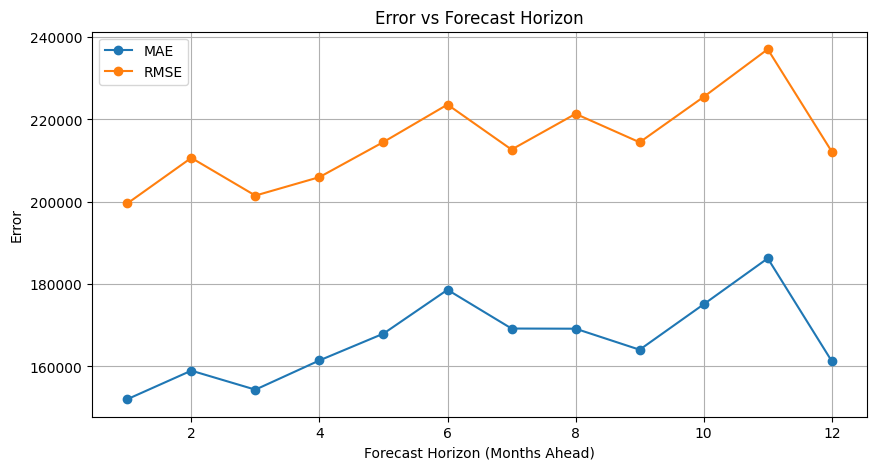

In [56]:
plt.figure(figsize=(10,5))

plt.plot(range(1,13), horizon_mae, marker='o', label='MAE')
plt.plot(range(1,13), horizon_rmse, marker='o', label='RMSE')

plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Error")
plt.title("Error vs Forecast Horizon")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
def forecast_2025_for_store(store_id):

    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date').copy()

    last_12 = store_data.tail(12)

    X_input = last_12[feature_cols].values
    X_input_scaled = scaler.transform(X_input)
    X_input_scaled = X_input_scaled.reshape(1, 12, len(feature_cols))

    y_pred_scaled = model.predict(X_input_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)[0]

    last_date = last_12['date'].iloc[-1]

    future_dates = [
        last_date + pd.DateOffset(months=i+1)
        for i in range(12)
    ]

    forecast_df = pd.DataFrame({
        "store_id": store_id,
        "date": future_dates,
        "forecast_2025": y_pred
    })

    return forecast_df

In [58]:
forecast_all_2025 = []

for store_id in monthly_df['store_id'].unique():
    forecast_store = forecast_2025_for_store(store_id)
    forecast_all_2025.append(forecast_store)

forecast_all_2025 = pd.concat(forecast_all_2025).reset_index(drop=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

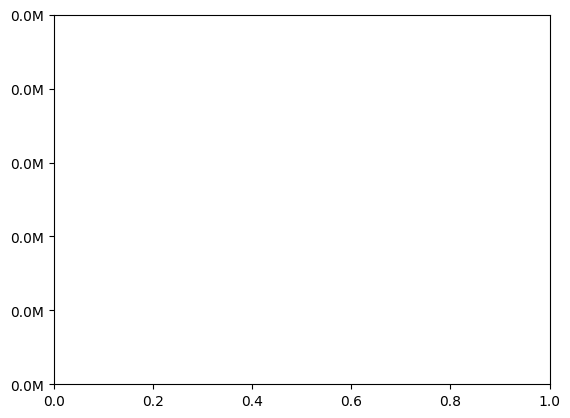

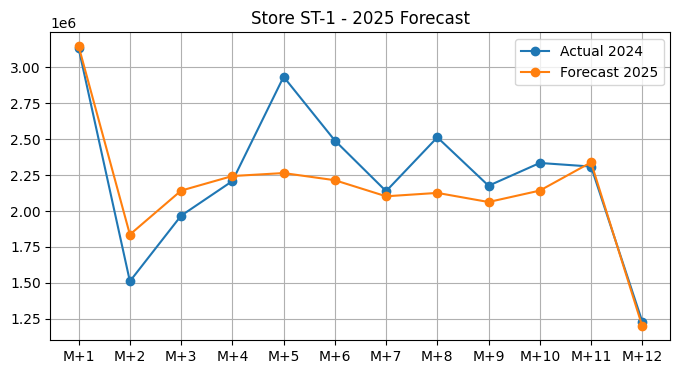

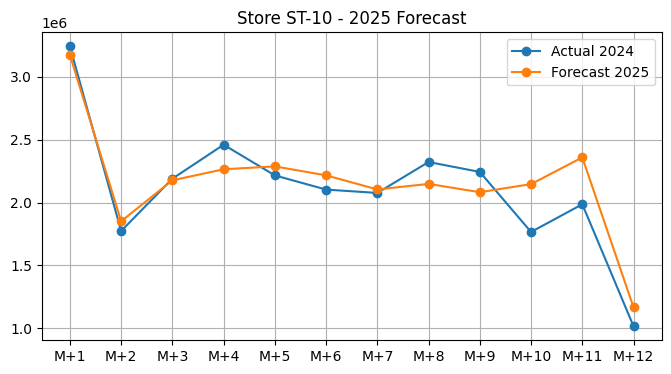

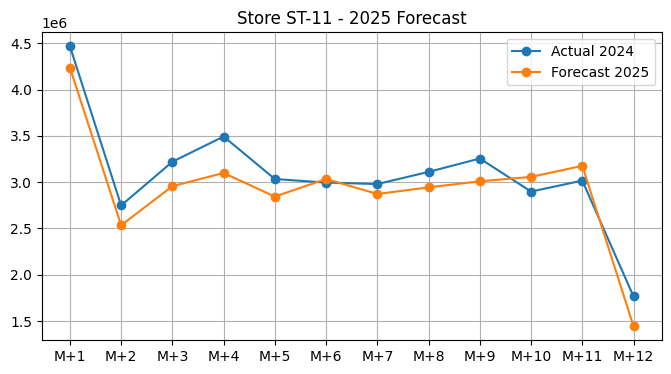

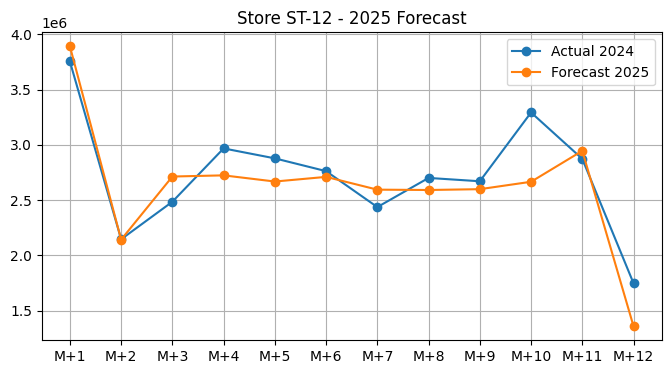

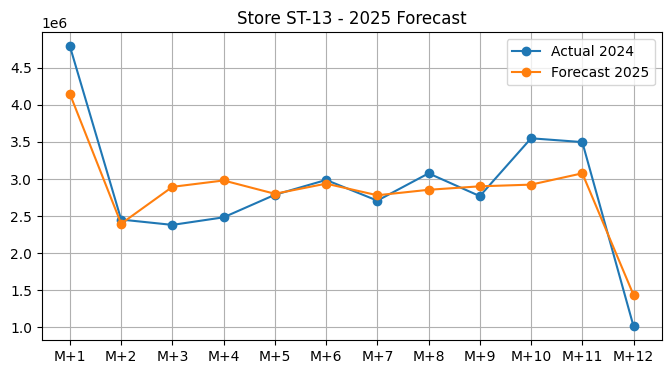

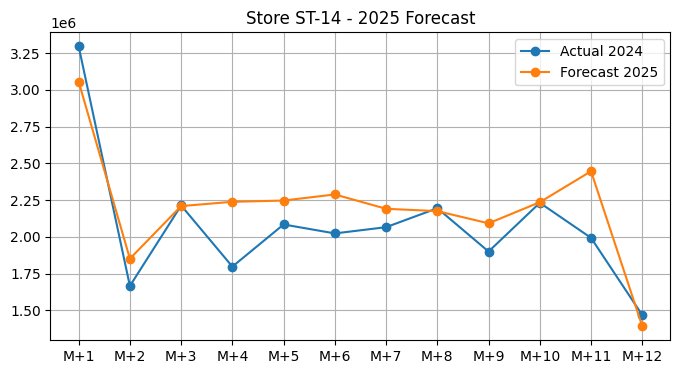

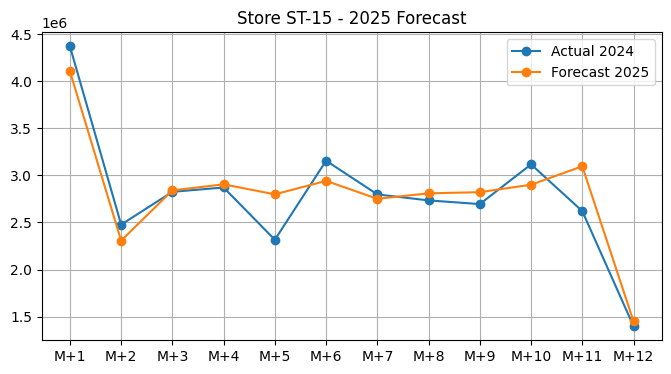

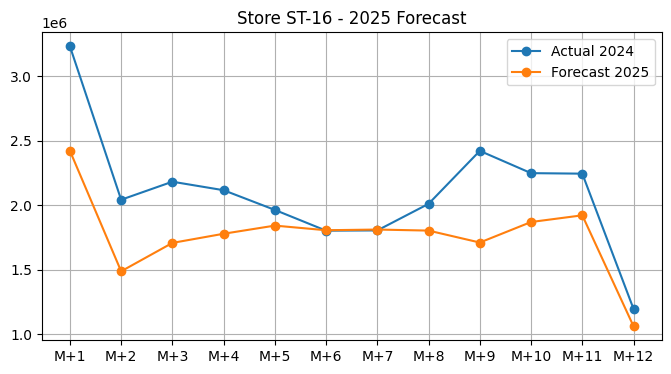

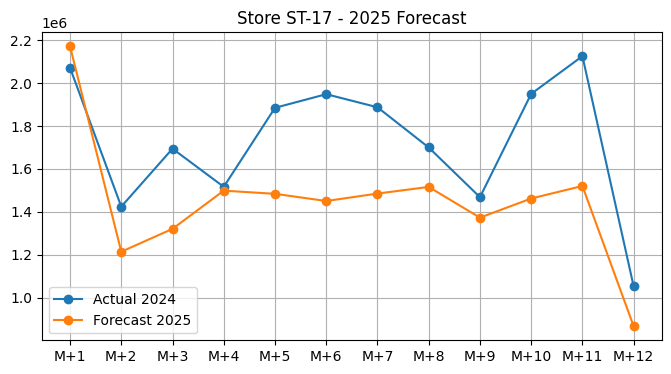

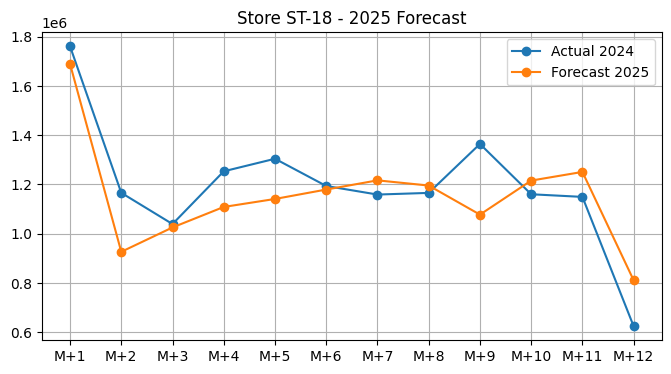

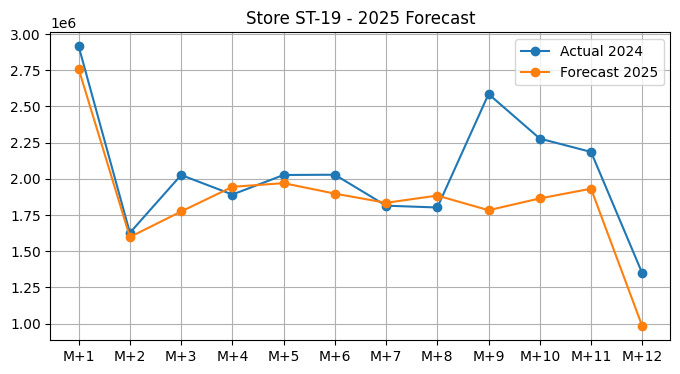

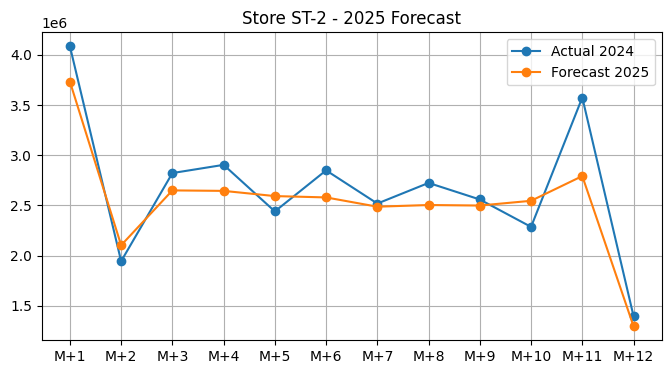

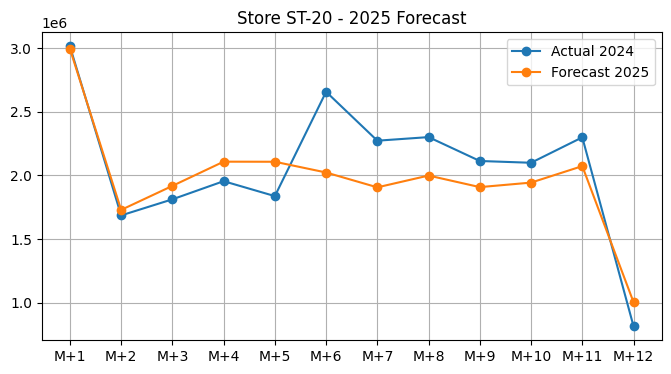

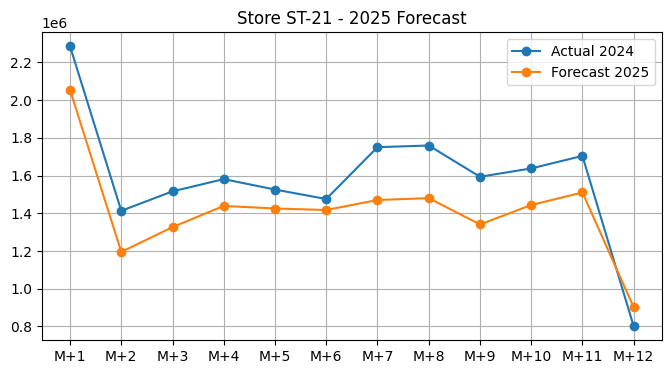

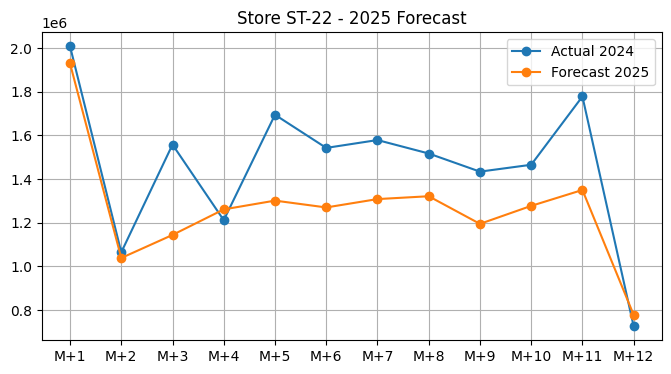

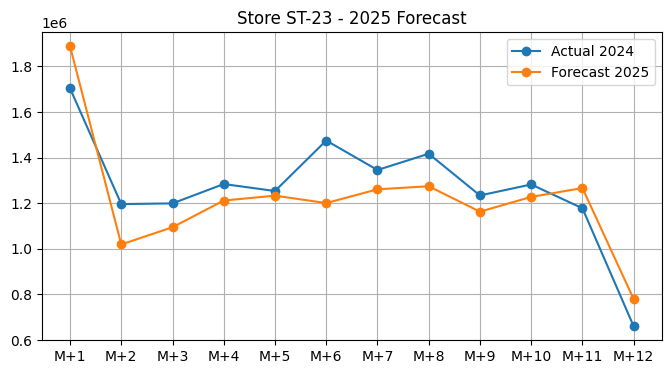

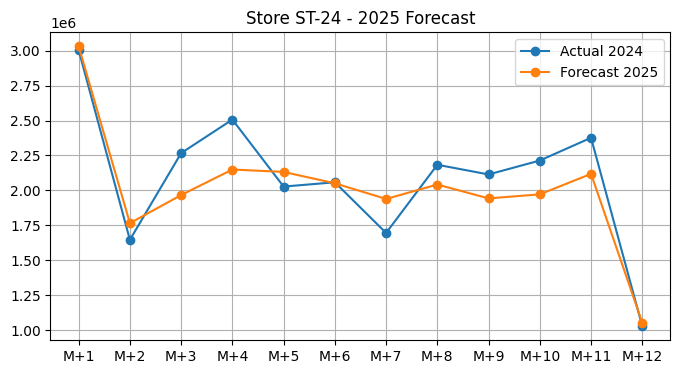

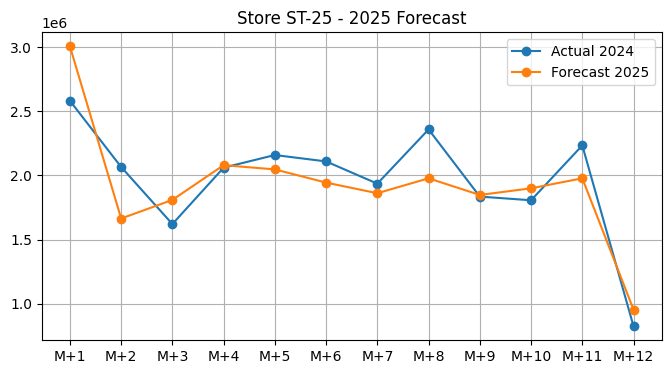

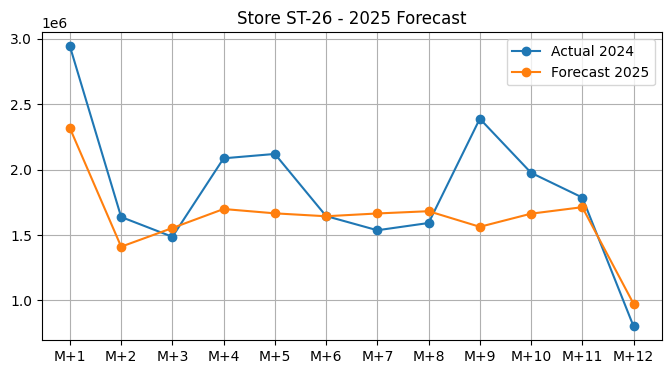

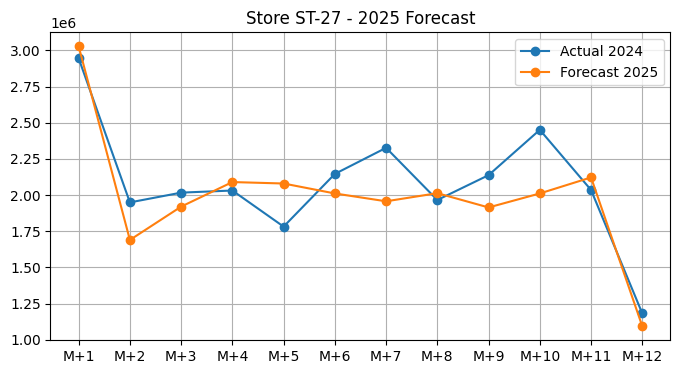

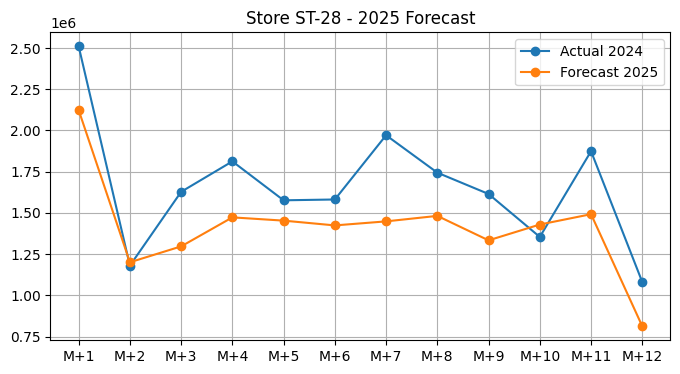

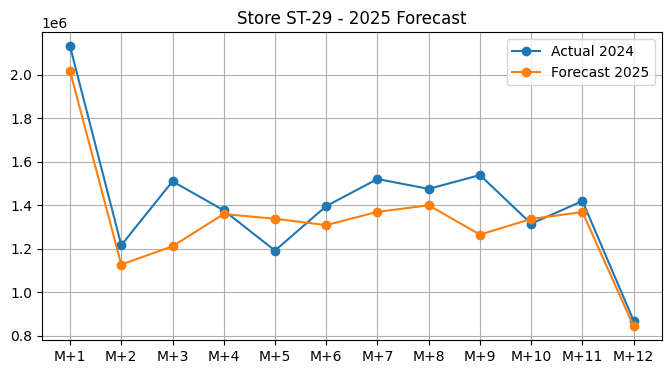

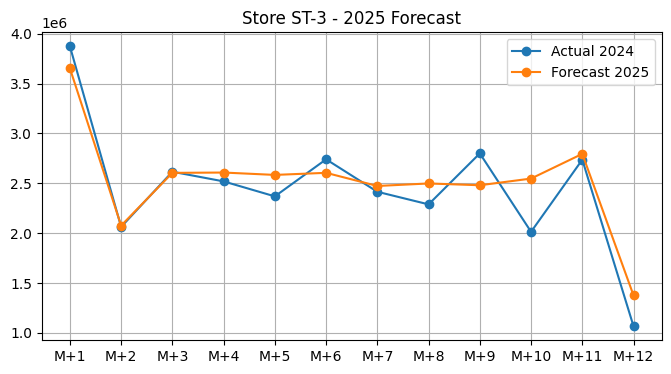

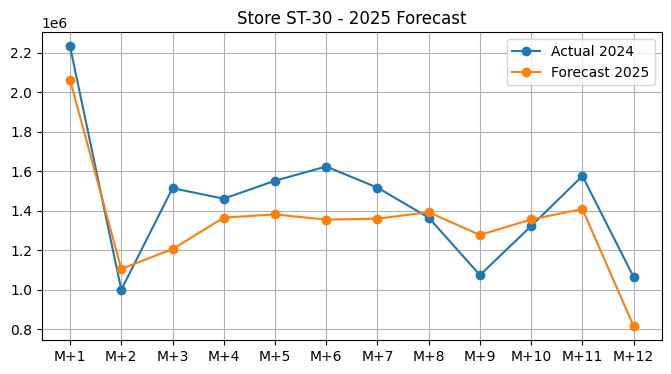

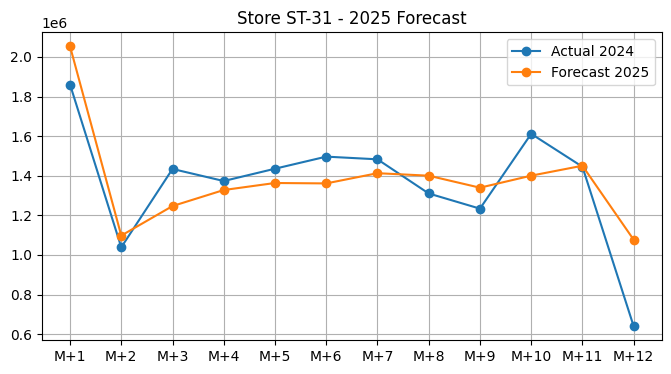

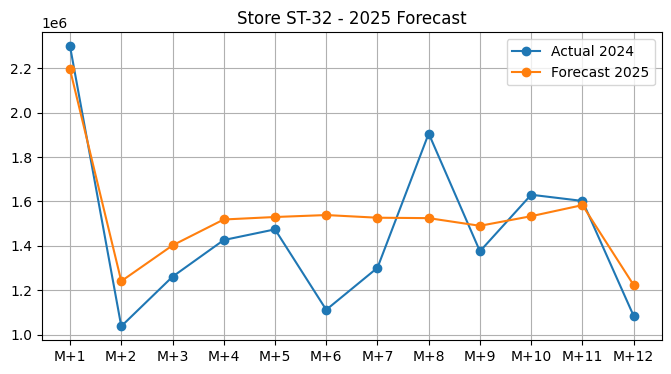

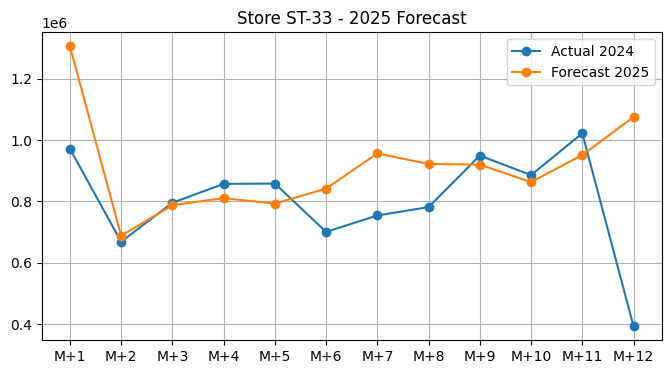

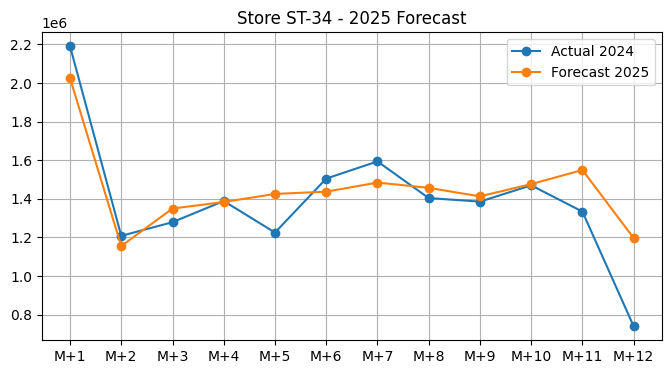

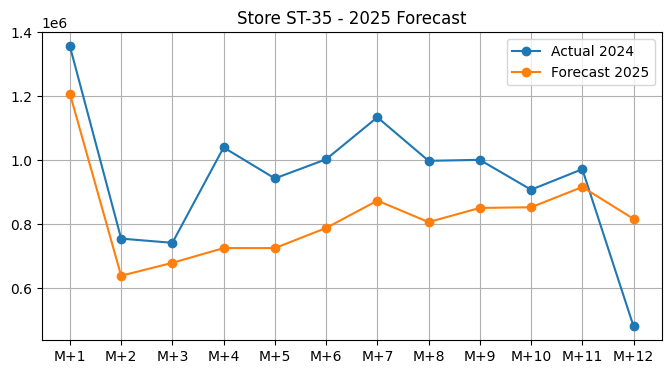

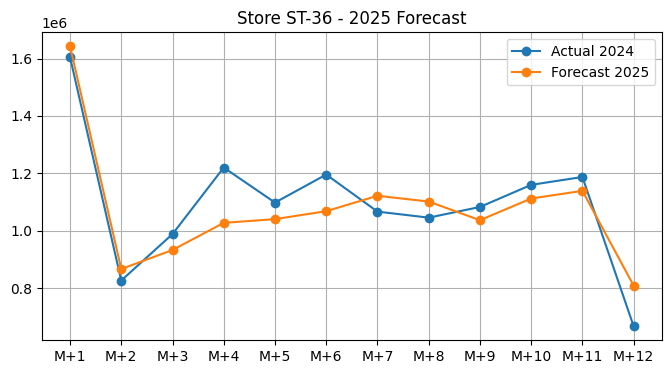

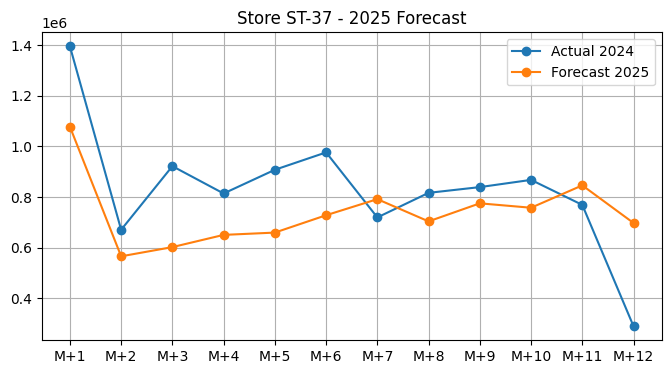

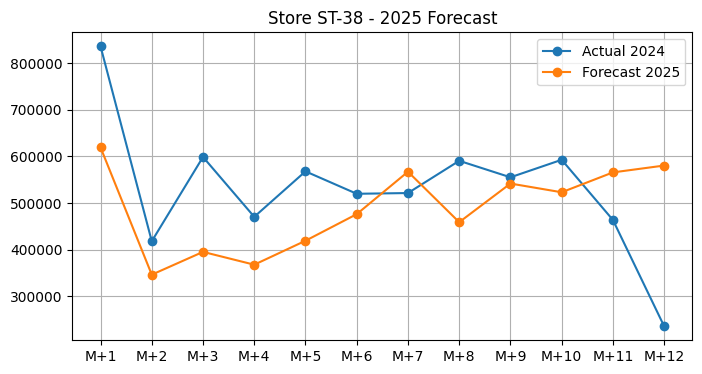

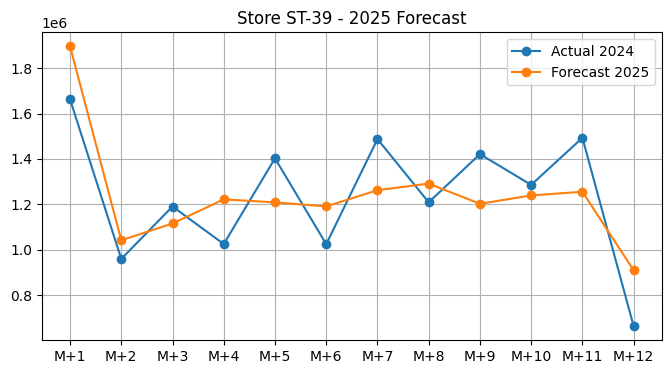

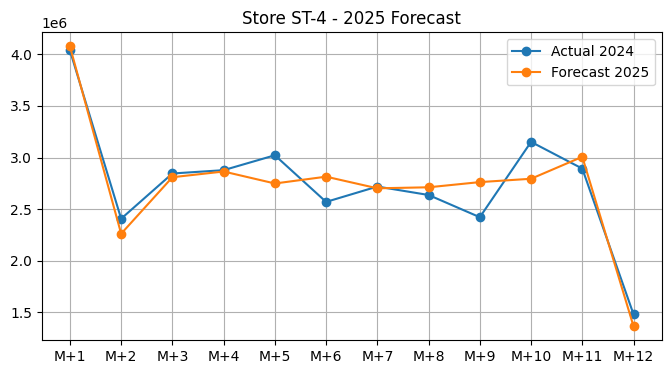

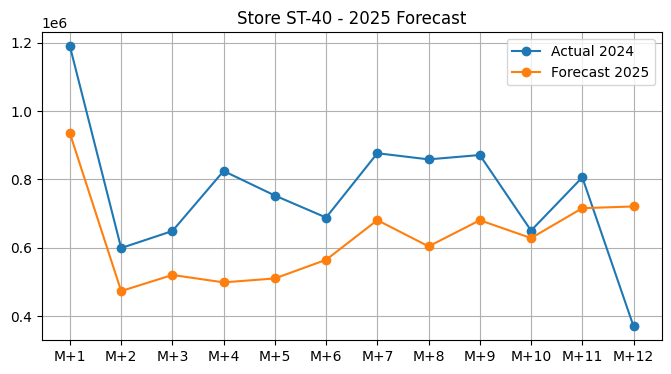

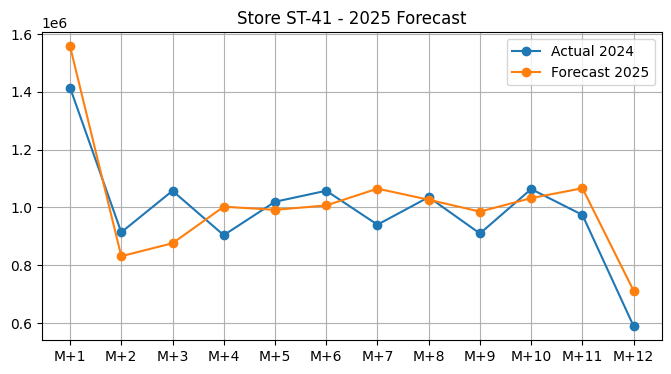

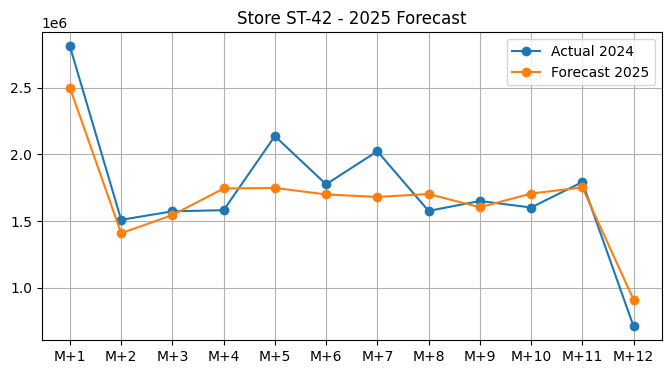

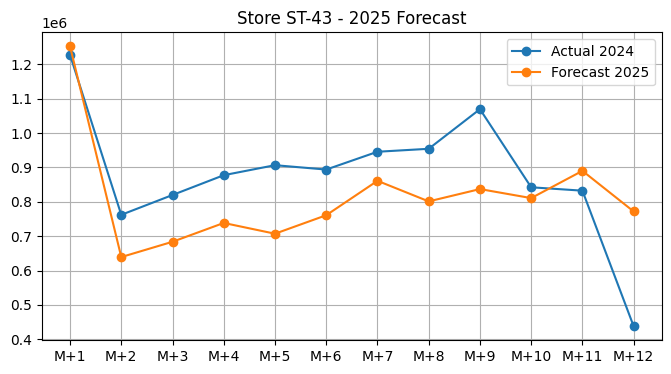

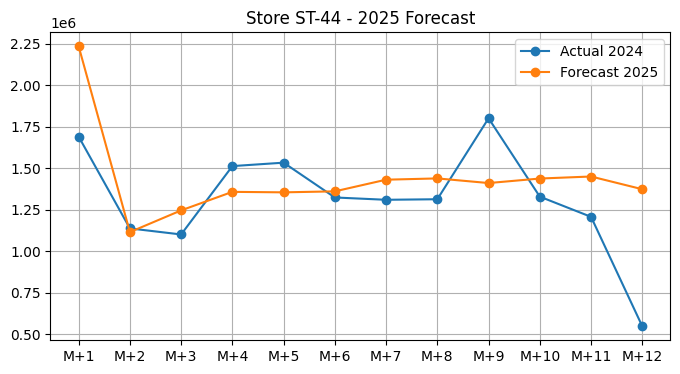

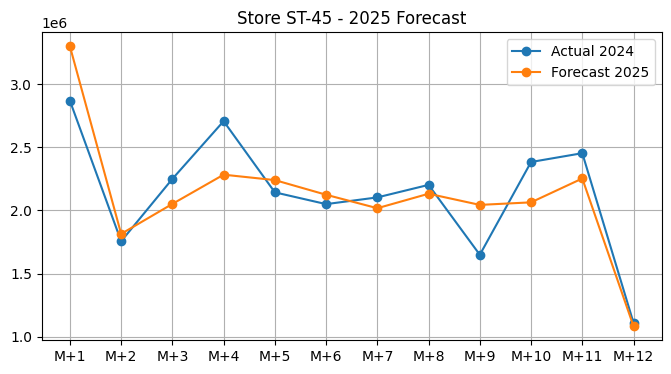

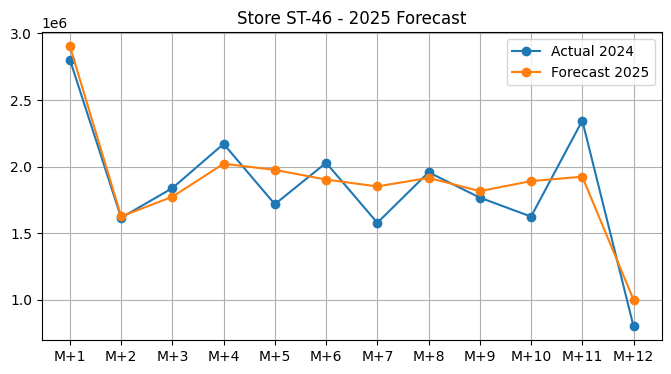

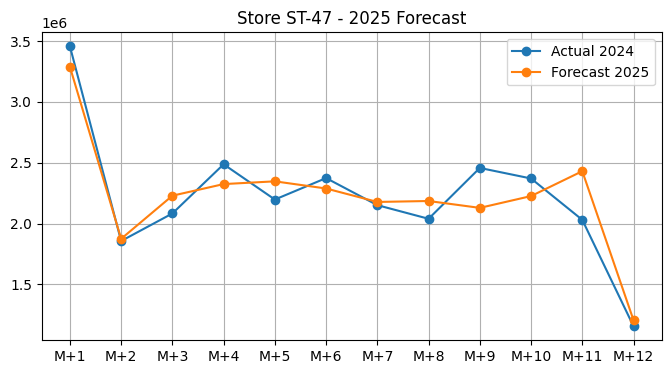

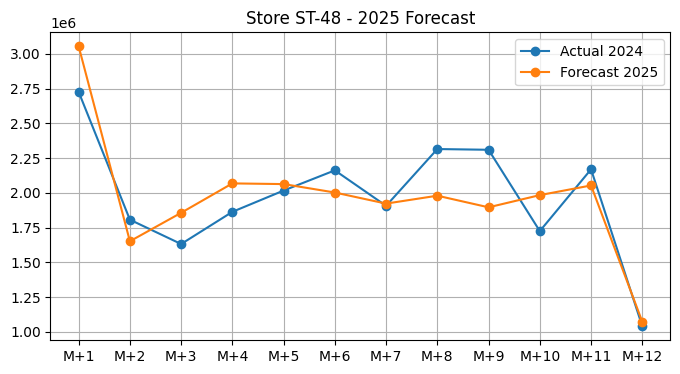

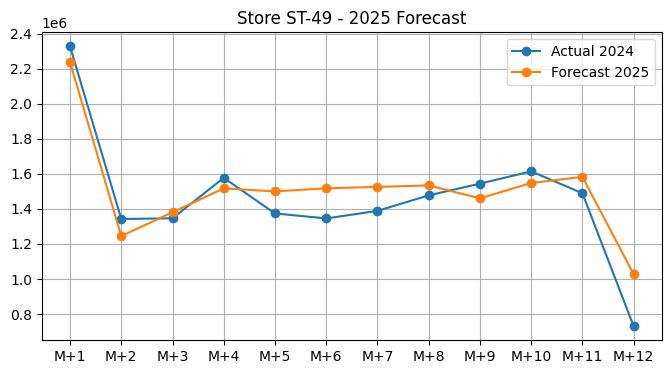

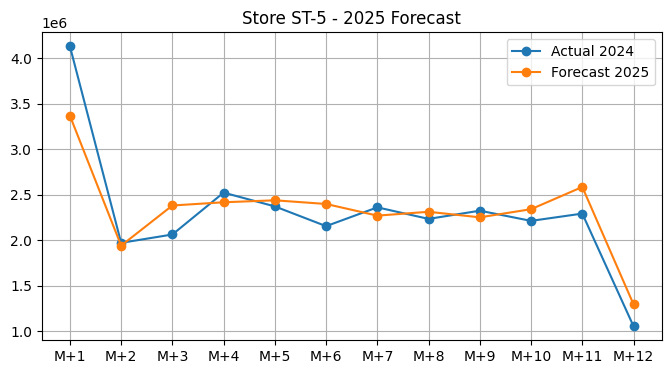

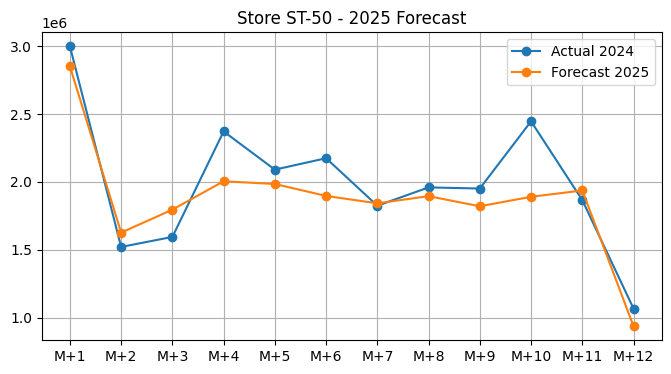

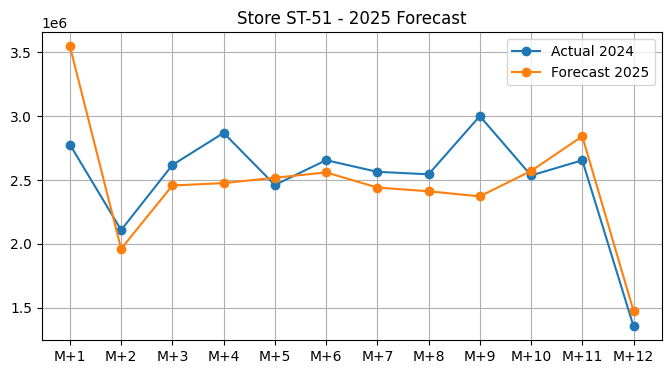

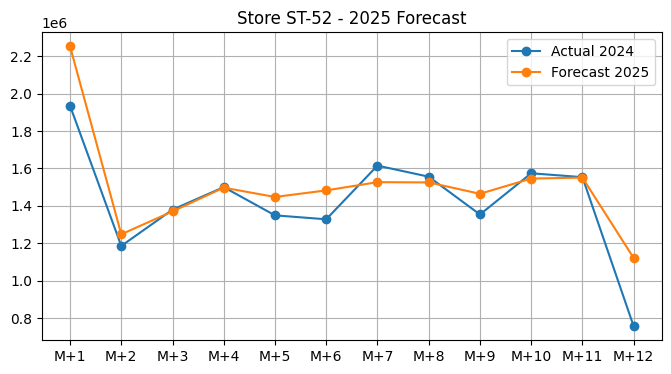

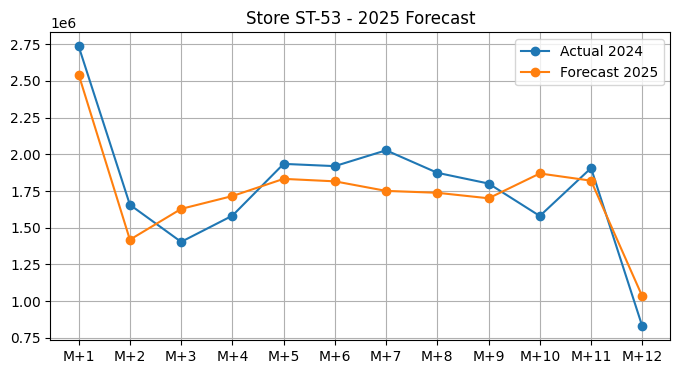

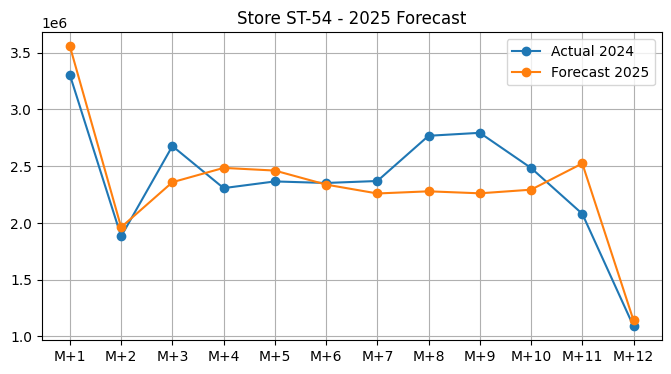

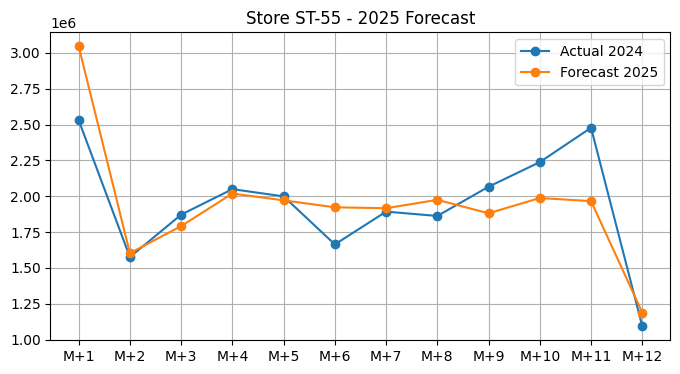

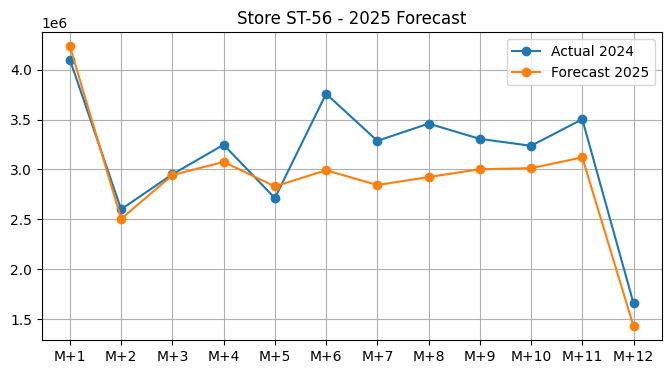

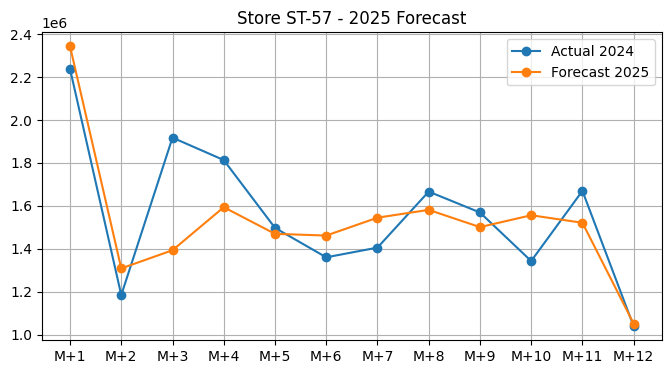

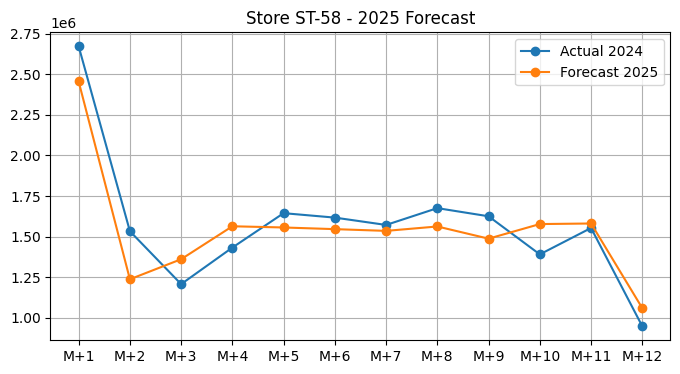

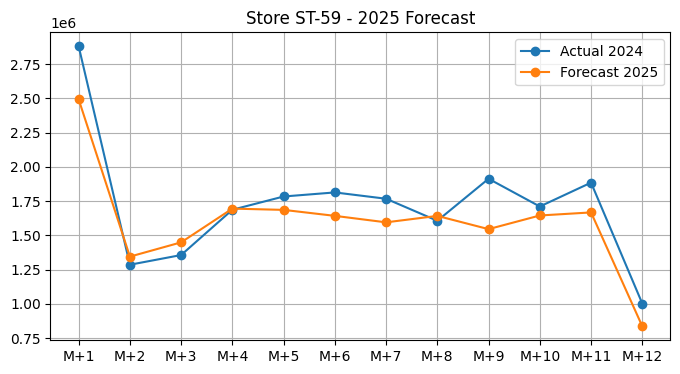

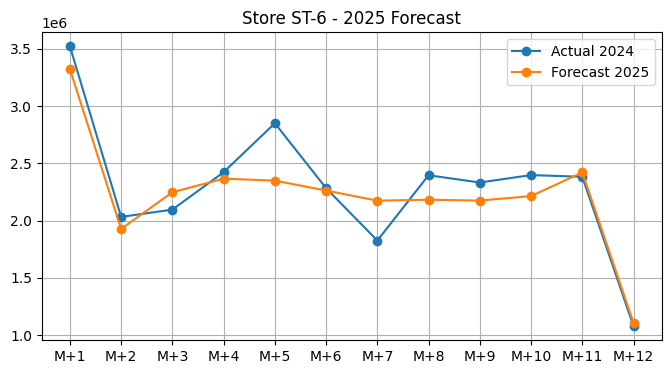

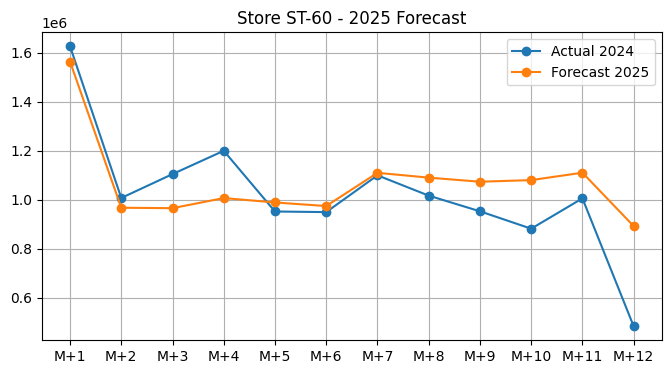

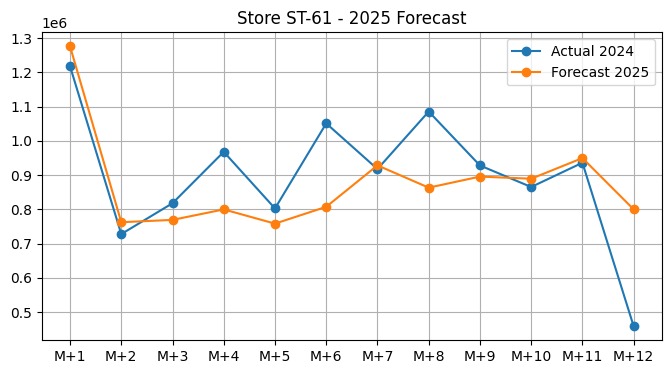

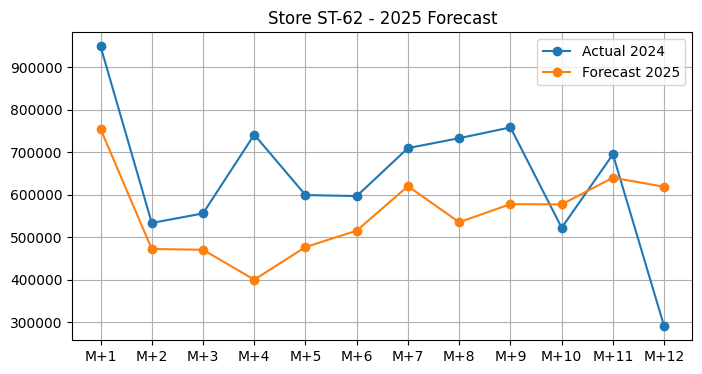

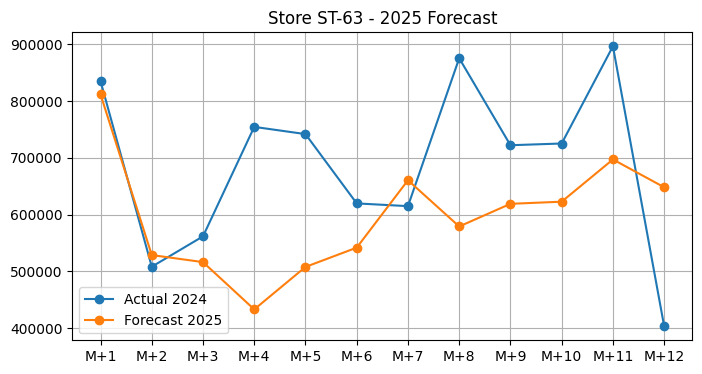

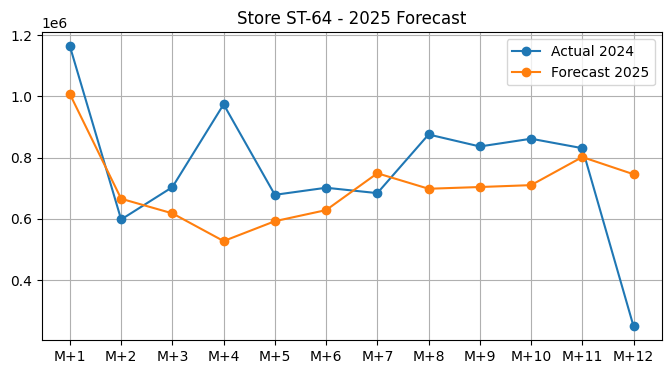

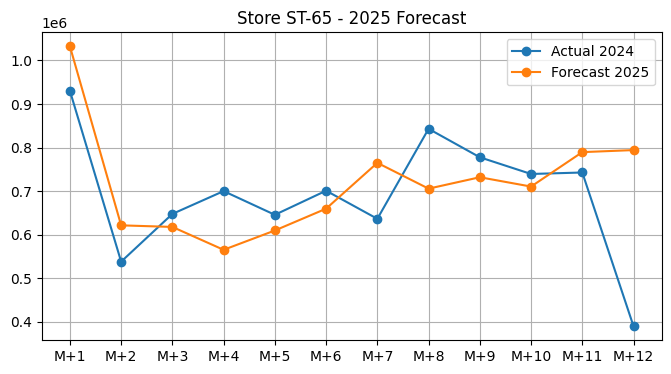

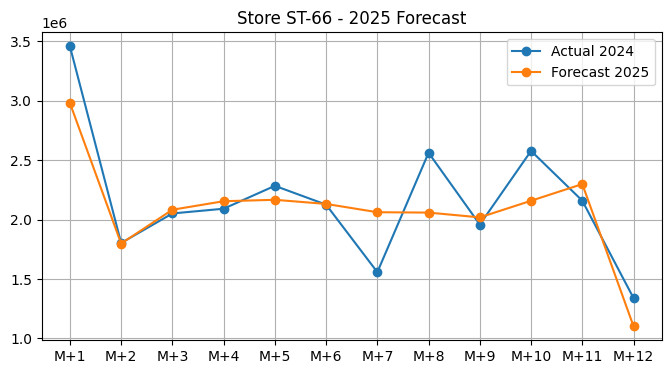

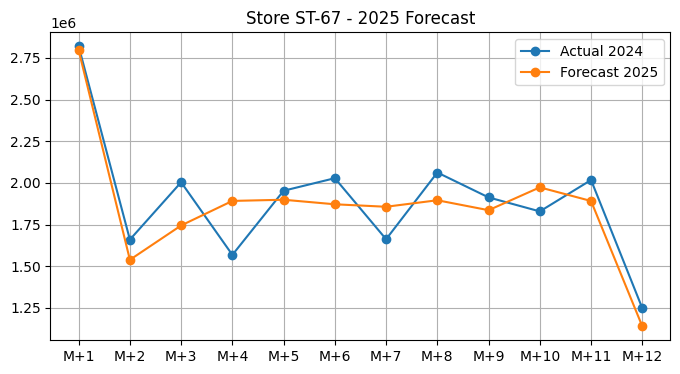

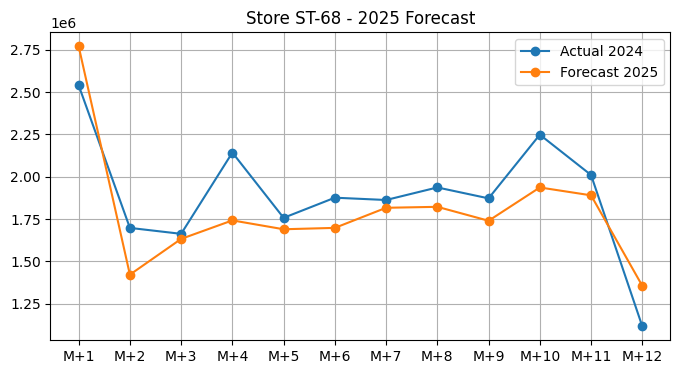

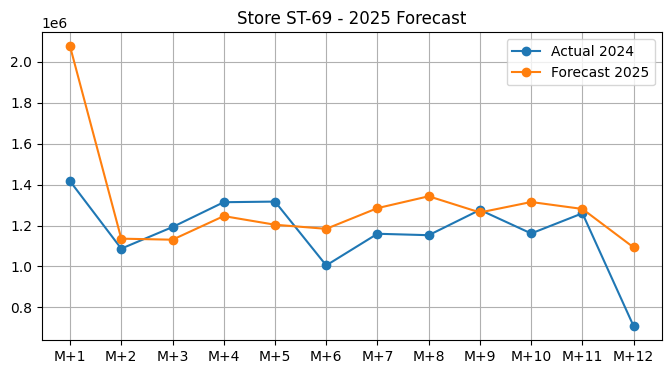

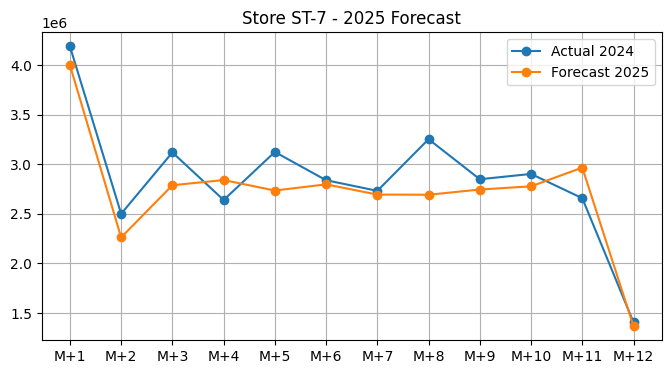

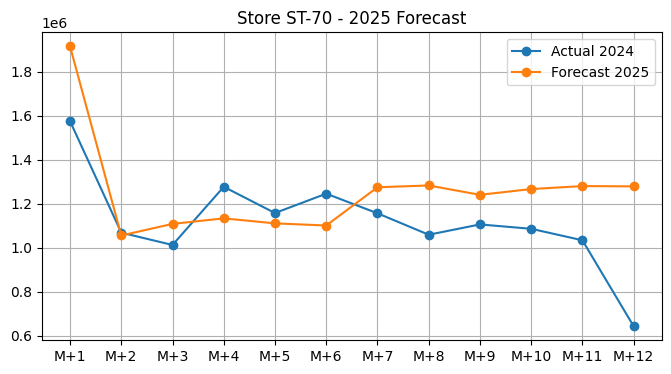

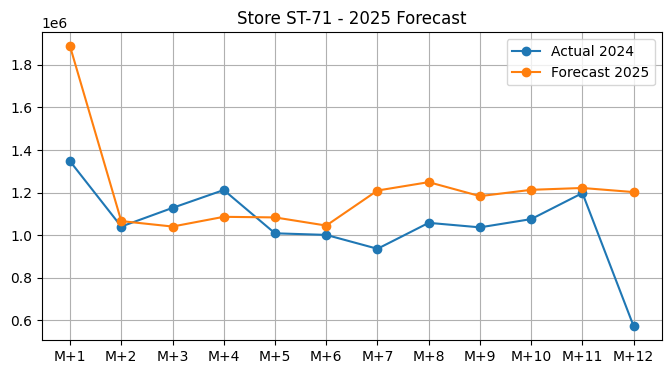

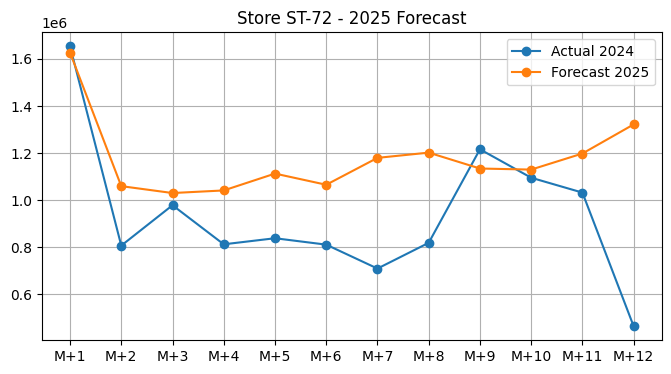

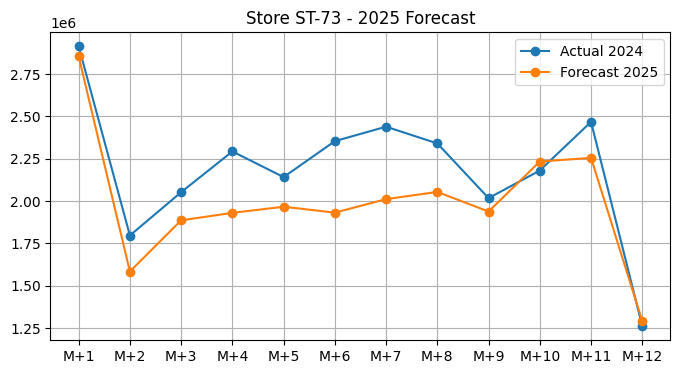

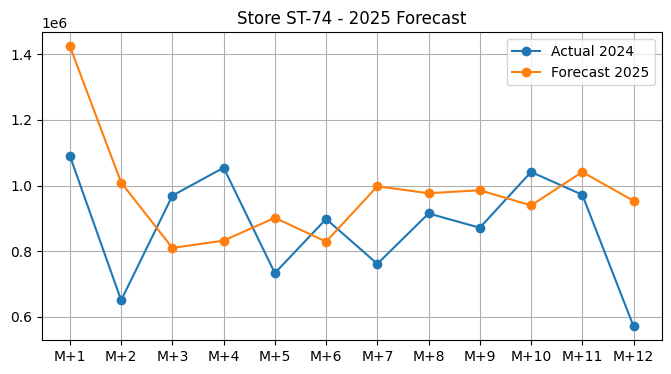

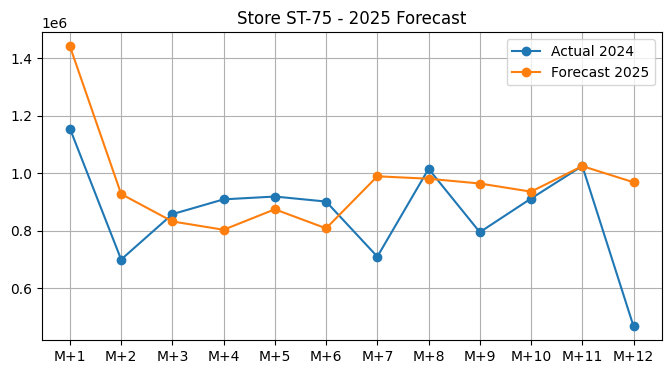

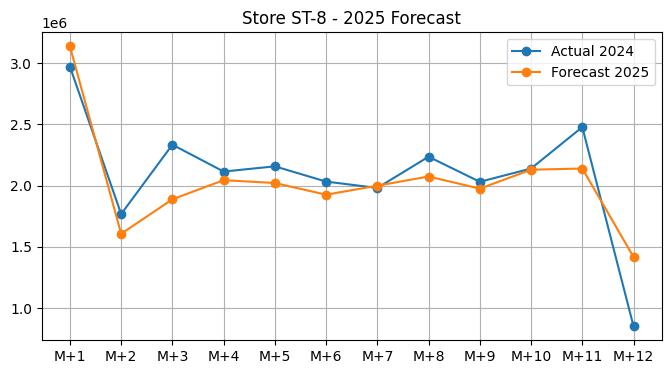

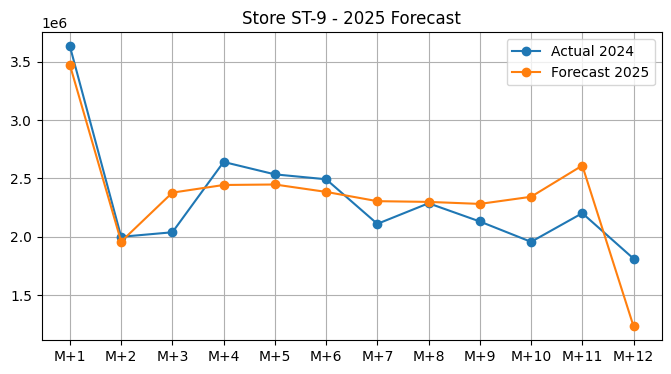

In [59]:
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M')
)
for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date')

    actual_2024 = store_data['sales_amount_realistic'].tail(12).values

    forecast_store = forecast_all_2025[
        forecast_all_2025['store_id'] == store_id
    ]

    forecast_2025 = forecast_store['forecast_2025'].values

    months = [f"M+{i}" for i in range(1,13)]

    plt.figure(figsize=(8,4))

    plt.plot(months, actual_2024, marker='o', label="Actual 2024")
    plt.plot(months, forecast_2025, marker='o', label="Forecast 2025")

    plt.title(f"Store {store_id} - 2025 Forecast")
    plt.legend()
    plt.grid(True)
    plt.show()

In [60]:
df.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


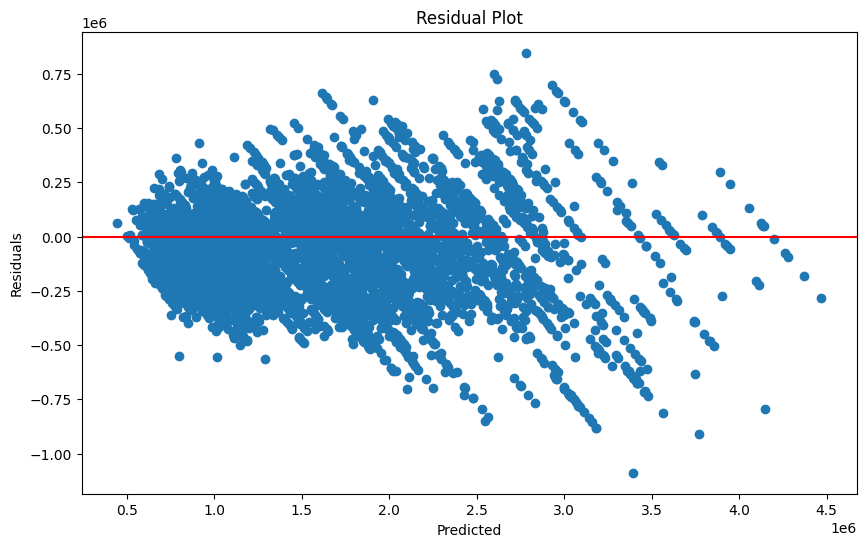

In [61]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

In [62]:
store_hist = monthly_df[monthly_df["store_id"] == "ST-10"]

store_hist.groupby("month")["sales_amount_realistic"].mean()

month
1     1.634706e+06
2     1.899634e+06
3     2.033501e+06
4     1.898875e+06
5     1.911850e+06
6     1.902655e+06
7     1.962935e+06
8     2.155262e+06
9     1.962761e+06
10    2.057777e+06
11    2.295897e+06
12    3.047234e+06
Name: sales_amount_realistic, dtype: float64

Top stores: ['ST-7', 'ST-9', 'ST-8', 'ST-73', 'ST-66', 'ST-67', 'ST-68', 'ST-69', 'ST-70', 'ST-71']
Bottom stores: ['ST-65', 'ST-64', 'ST-74', 'ST-75', 'ST-72', 'ST-71', 'ST-70', 'ST-69', 'ST-68', 'ST-67']


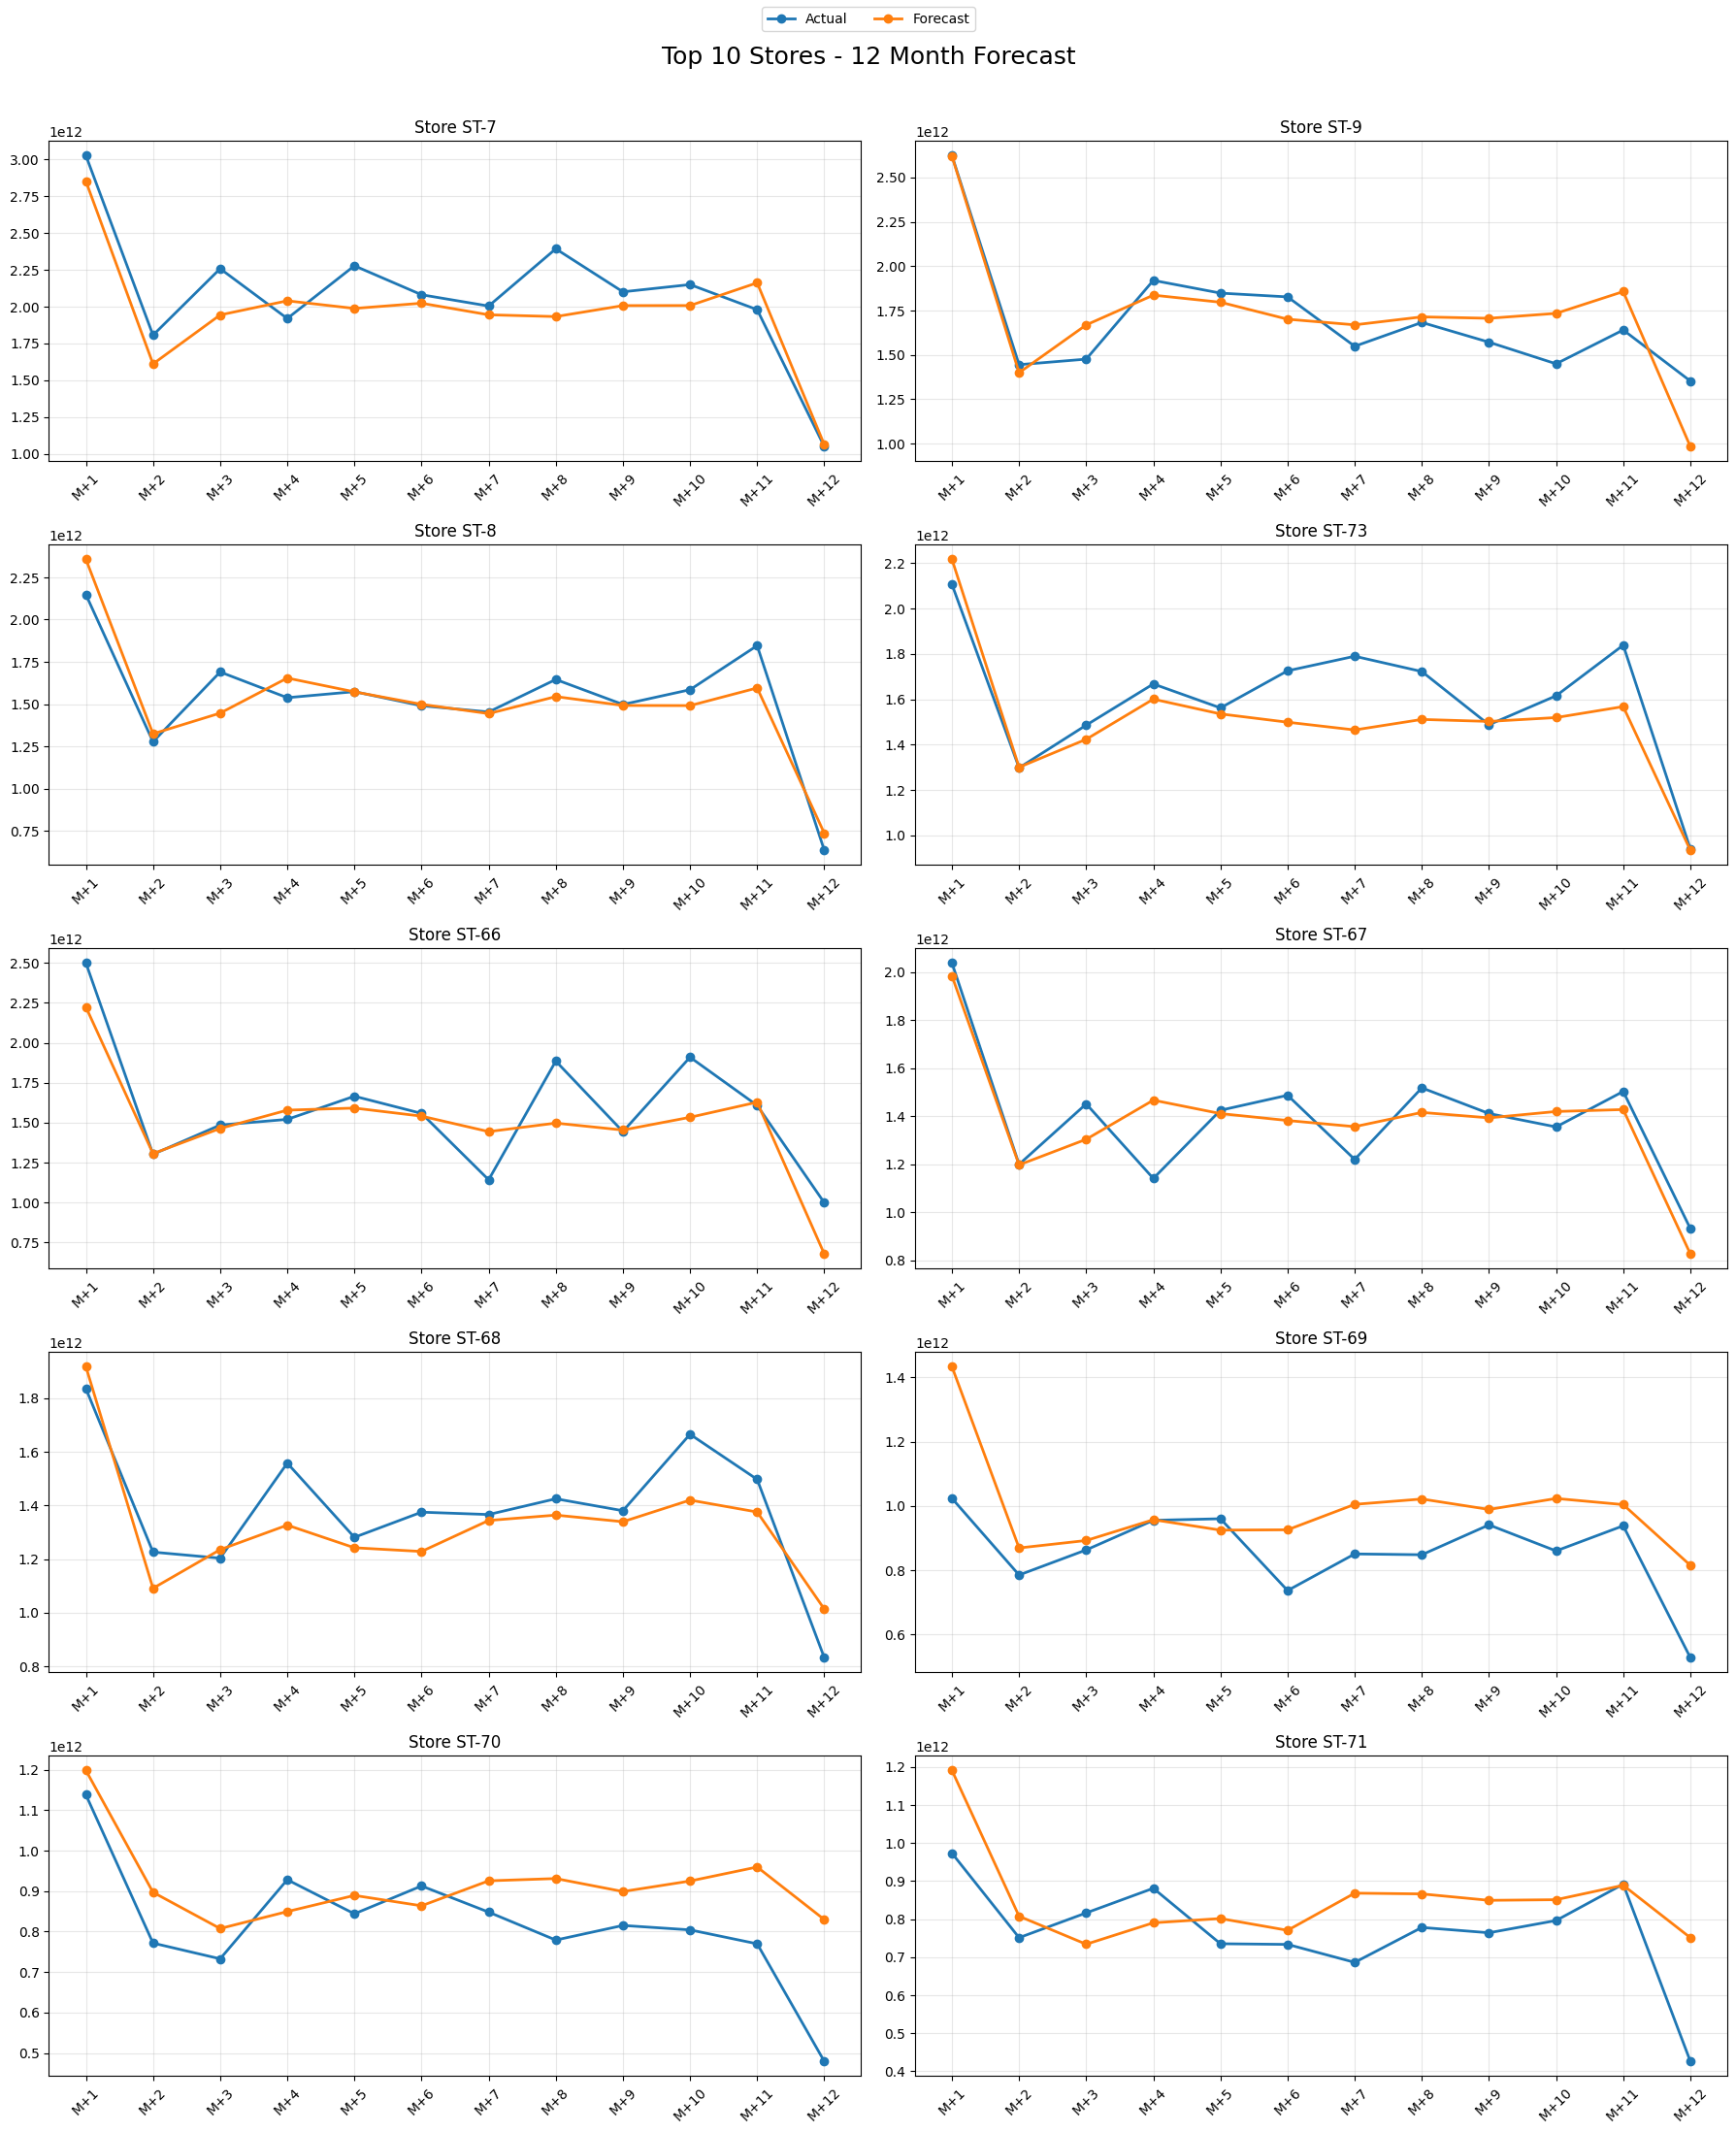

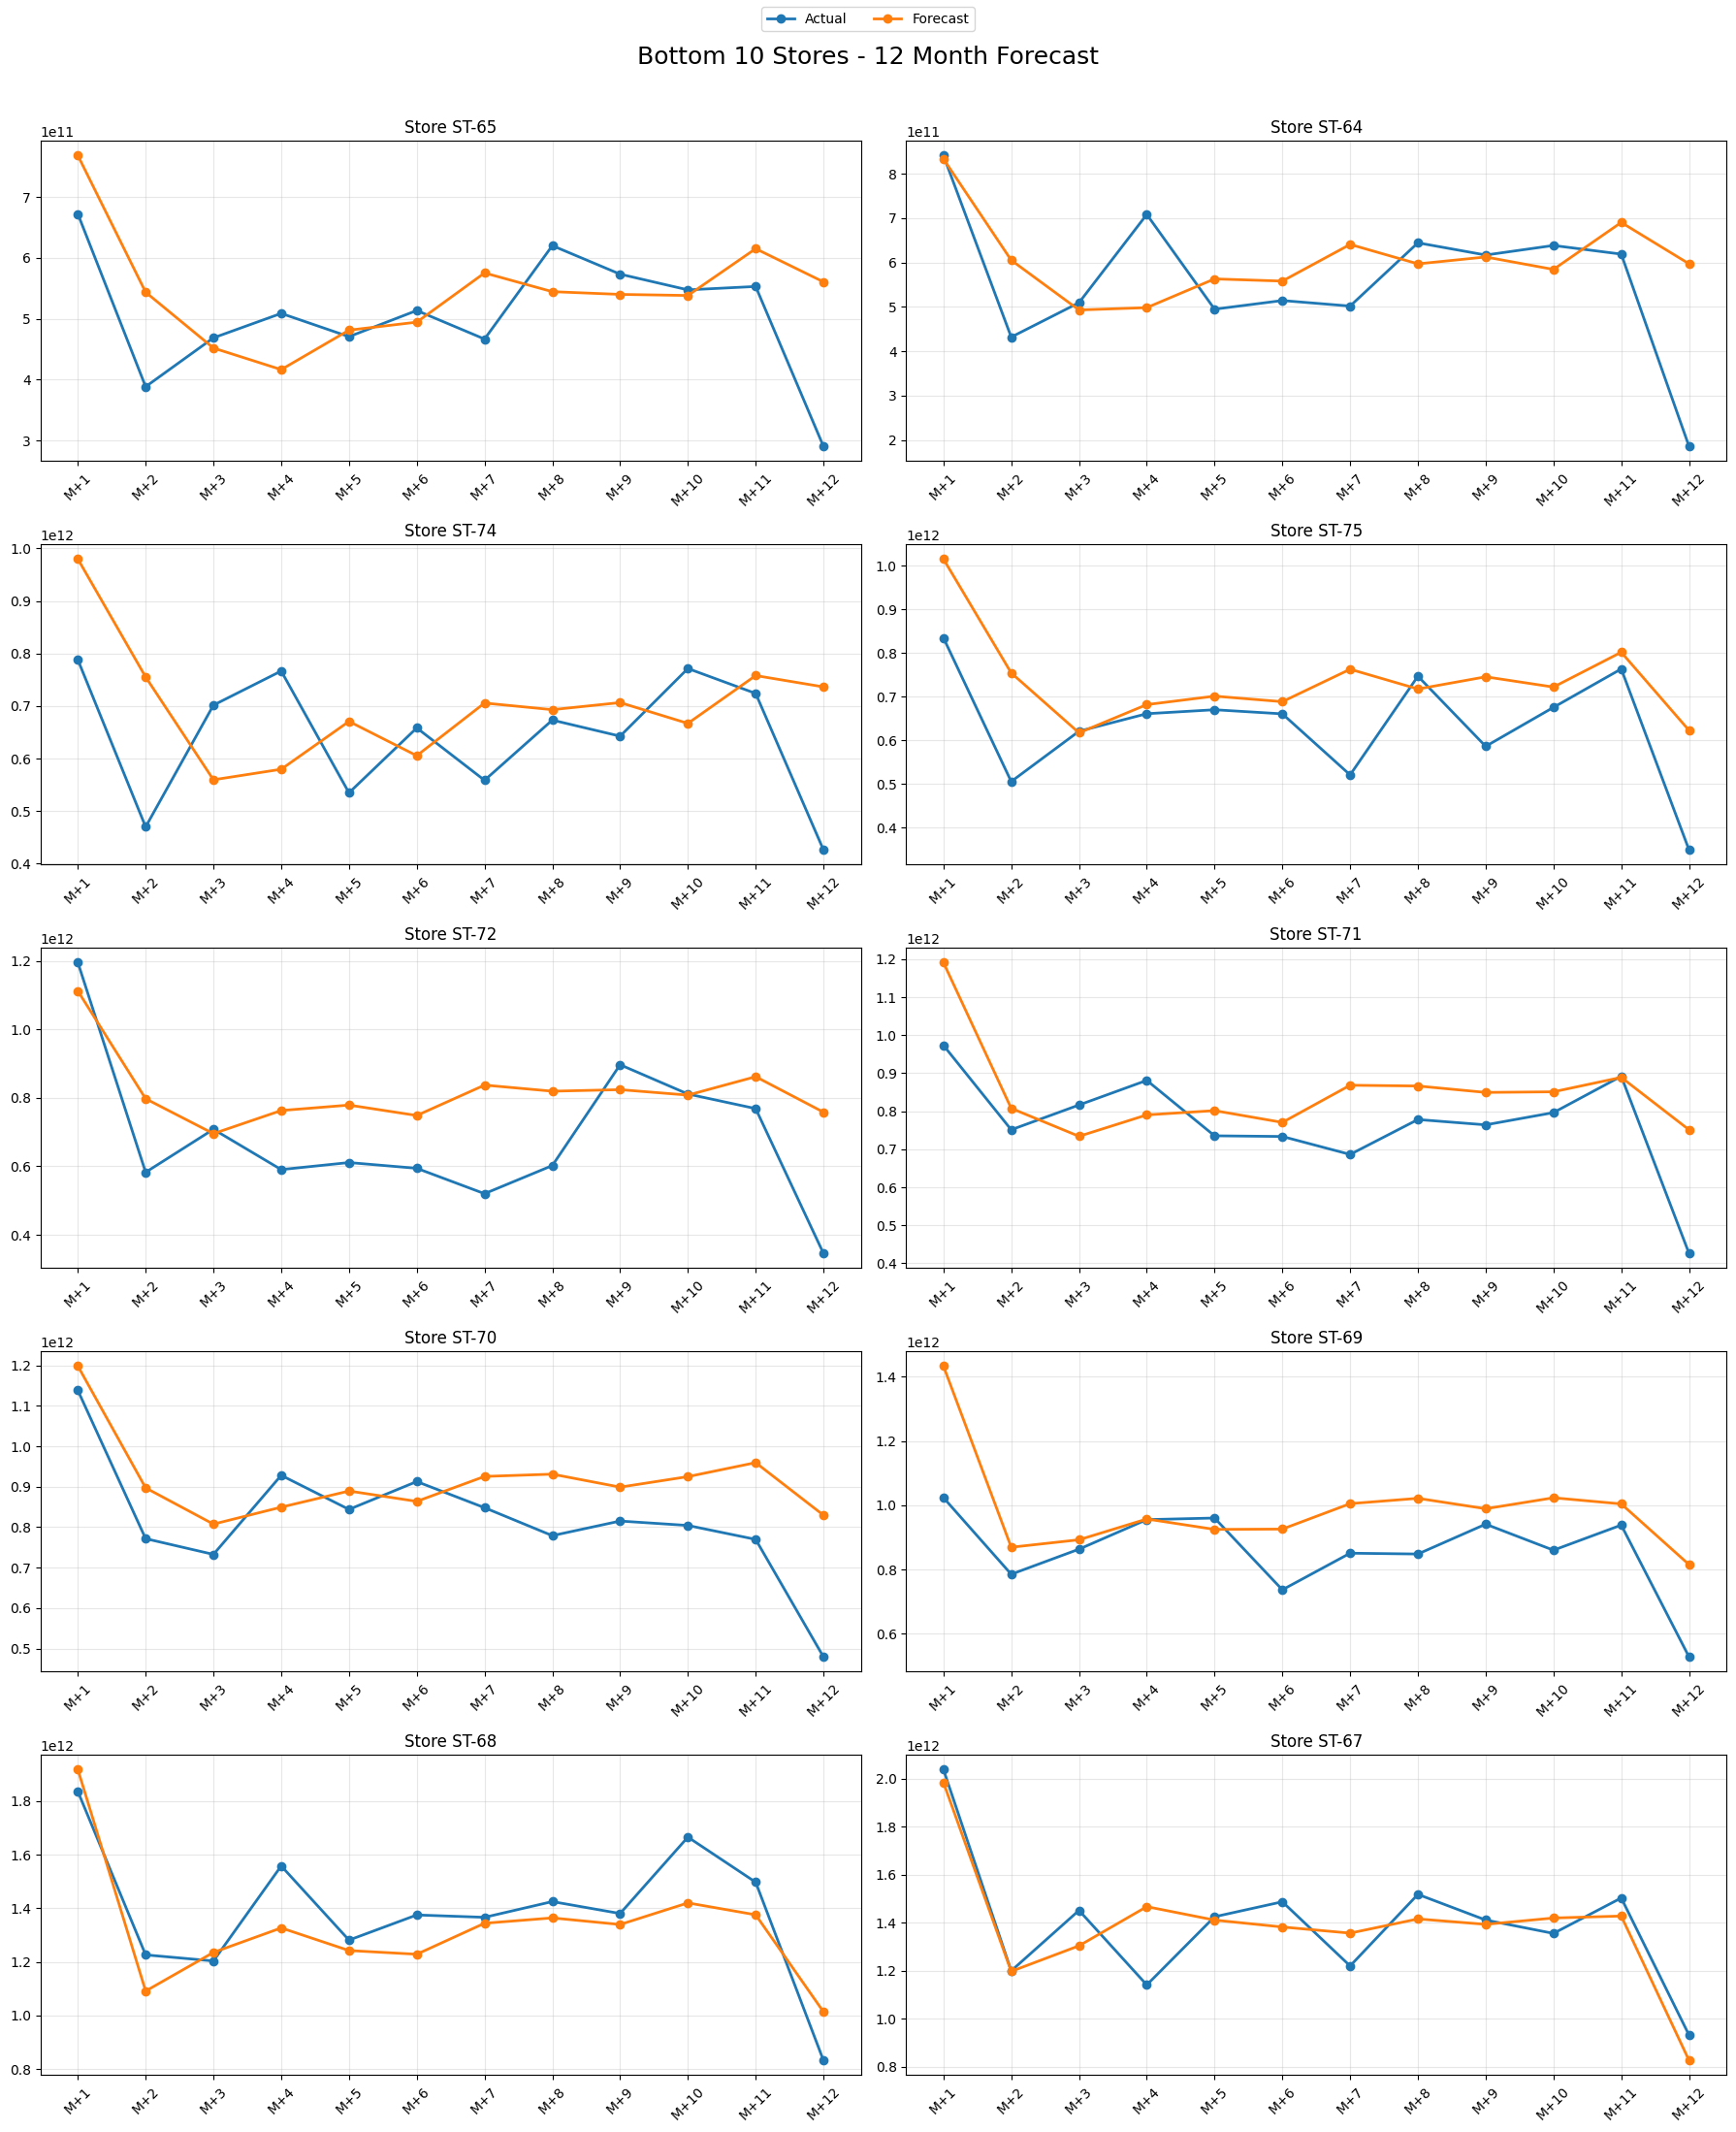

In [67]:
# ------------------------------------------------------------
# Get the store_id for every test sample correctly
# ------------------------------------------------------------
# If you split with:
# split_idx = int(len(X_seq) * 0.8)
# X_test = X_seq[split_idx:]

encoded_test_store_ids = X_test[:, -1, 0].astype(int)

store_mapping = (
    monthly_df[["store_id_encoded", "store_id"]]
    .drop_duplicates()
    .set_index("store_id_encoded")["store_id"]
    .to_dict()
)

test_store_ids = [store_mapping[s] for s in encoded_test_store_ids]

# ------------------------------------------------------------
# Inverse transform
# ------------------------------------------------------------
y_pred_inv = y_scaler.inverse_transform(y_pred)
y_test_inv = y_scaler.inverse_transform(y_test)

# ------------------------------------------------------------
# Create one row per sample
# ------------------------------------------------------------
forecast_summary = pd.DataFrame({
    "store_id": test_store_ids,
    "actual_total": np.sum(y_test_inv, axis=1),
    "pred_total": np.sum(y_pred_inv, axis=1)
})

# ------------------------------------------------------------
# For each store keep the latest forecast sample only
# This avoids repeating the same store many times
# ------------------------------------------------------------
forecast_summary = forecast_summary.reset_index()

latest_store_forecasts = (
    forecast_summary.sort_values("index")
    .groupby("store_id", as_index=False)
    .tail(1)
)

# ------------------------------------------------------------
# Top / Bottom 10 stores
# ------------------------------------------------------------
top10_stores = (
    latest_store_forecasts
    .sort_values("pred_total", ascending=False)
    .head(10)["store_id"]
    .tolist()
)

bottom10_stores = (
    latest_store_forecasts
    .sort_values("pred_total", ascending=True)
    .head(10)["store_id"]
    .tolist()
)

print("Top stores:", top10_stores)
print("Bottom stores:", bottom10_stores)

# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------
def plot_store_group(store_ids, title):
    fig, axes = plt.subplots(5, 2, figsize=(18, 22))
    axes = axes.flatten()

    for ax, store in zip(axes, store_ids):

        # last sample belonging to that store
        idx = np.where(np.array(test_store_ids) == store)[0][-1]

        actual = y_test_inv[idx]
        pred = y_pred_inv[idx]

        months = np.arange(1, 13)

        ax.plot(months, actual, marker="o", linewidth=2, label="Actual")
        ax.plot(months, pred, marker="o", linewidth=2, label="Forecast")

        ax.set_title(f"Store {store}")
        ax.set_xticks(months)
        ax.set_xticklabels([f"M+{m}" for m in months], rotation=45)
        ax.grid(True, alpha=0.3)

    # hide unused axes if fewer than 10 stores
    for i in range(len(store_ids), len(axes)):
        axes[i].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    fig.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# ------------------------------------------------------------
# Draw top and bottom 10
# ------------------------------------------------------------
plot_store_group(top10_stores, "Top 10 Stores - 12 Month Forecast")
plot_store_group(bottom10_stores, "Bottom 10 Stores - 12 Month Forecast")

In [70]:
forecast_summary["growth"] = (
    forecast_summary["pred_total"] - forecast_summary["actual_total"]
)

worst10 = (
    forecast_summary
    .sort_values("growth")
    .head(10)
)

best10 = (
    forecast_summary
    .sort_values("growth", ascending=False)
    .head(10)
)

print("Worst 10 stores:")
print(worst10[["store_id", "actual_total", "pred_total", "growth"]])

print("\nBest 10 stores:")
print(best10[["store_id", "actual_total", "pred_total", "growth"]])

Worst 10 stores:
    store_id  actual_total    pred_total        growth
248     ST-7  2.697428e+13  2.517152e+13 -1.802761e+12
251     ST-7  2.504457e+13  2.357155e+13 -1.473019e+12
249     ST-7  2.693624e+13  2.547504e+13 -1.461199e+12
242     ST-7  2.628319e+13  2.485610e+13 -1.427085e+12
247     ST-7  2.698329e+13  2.561423e+13 -1.369060e+12
162    ST-68  1.477055e+13  1.342110e+13 -1.349454e+12
163    ST-68  1.497775e+13  1.368627e+13 -1.291475e+12
246     ST-7  2.704797e+13  2.581556e+13 -1.232416e+12
164    ST-68  1.497193e+13  1.374527e+13 -1.226666e+12
395    ST-73  1.923652e+13  1.807309e+13 -1.163431e+12

Best 10 stores:
    store_id  actual_total    pred_total        growth
373    ST-73  1.361330e+13  1.706842e+13  3.455119e+12
371    ST-73  1.351891e+13  1.671735e+13  3.198443e+12
372    ST-73  1.348835e+13  1.633900e+13  2.850644e+12
374    ST-73  1.383297e+13  1.635278e+13  2.519806e+12
78     ST-66  1.566408e+13  1.811014e+13  2.446063e+12
370    ST-73  1.386102e+13  1.6

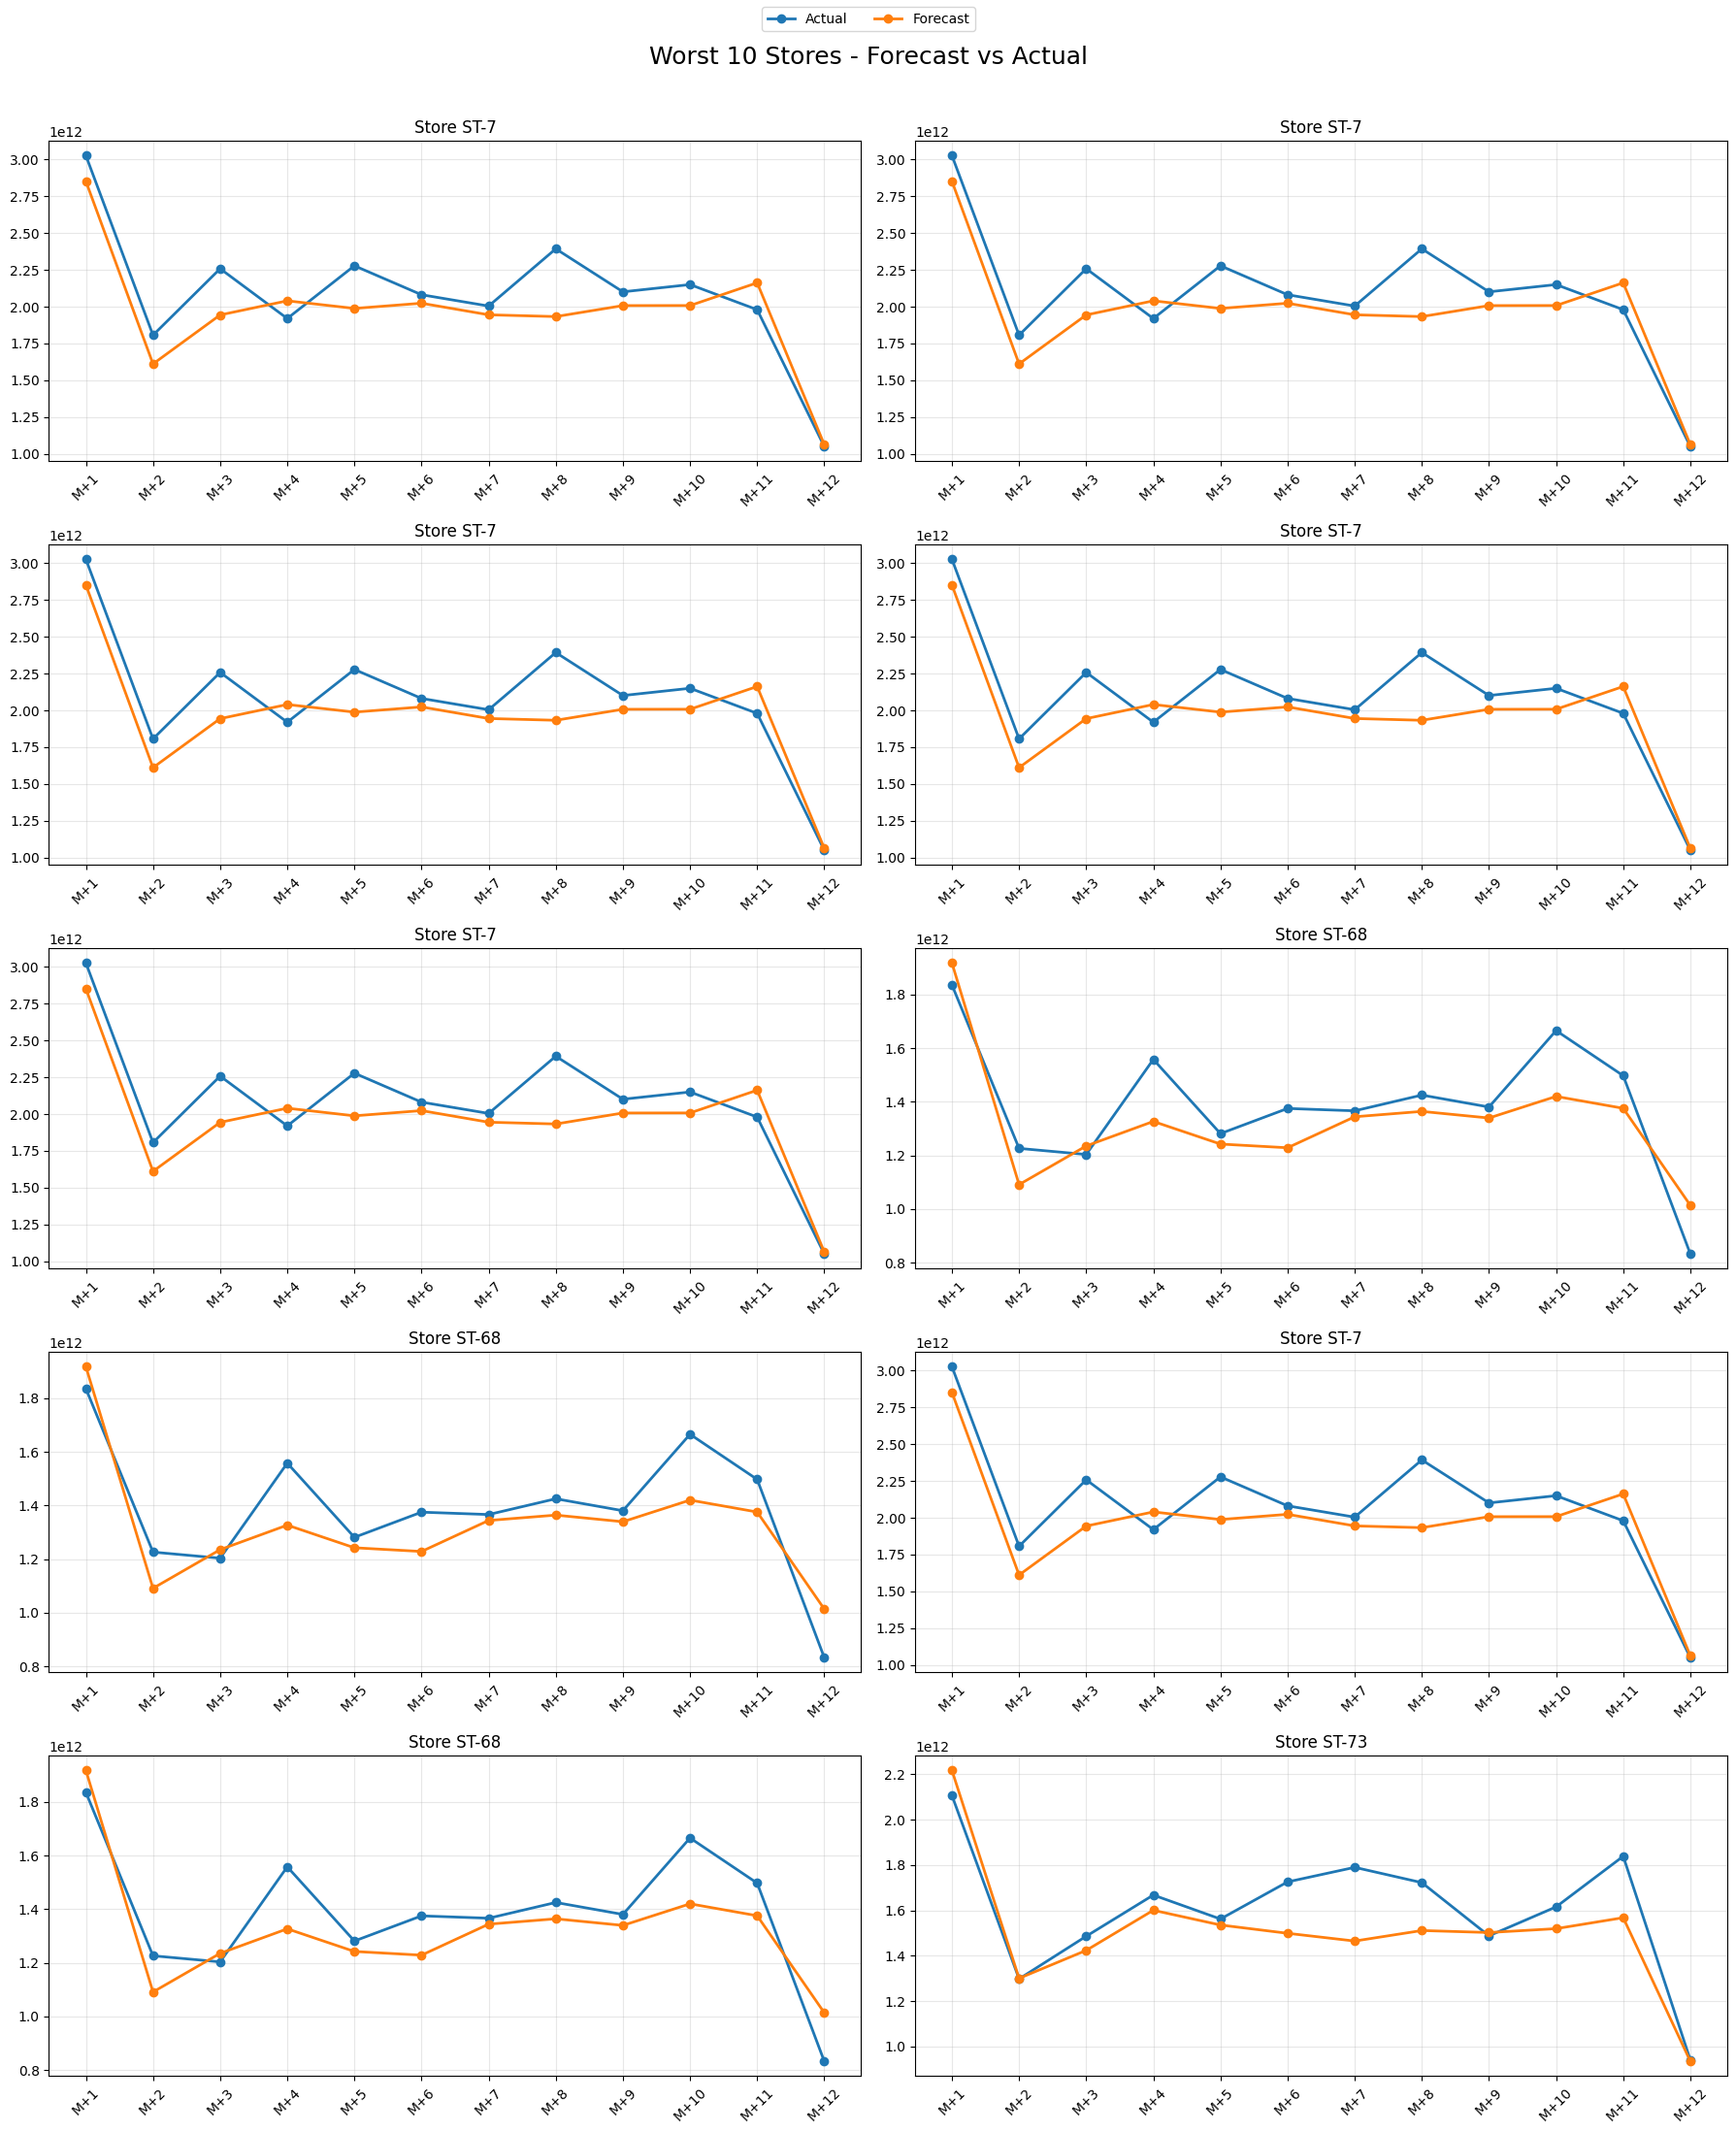

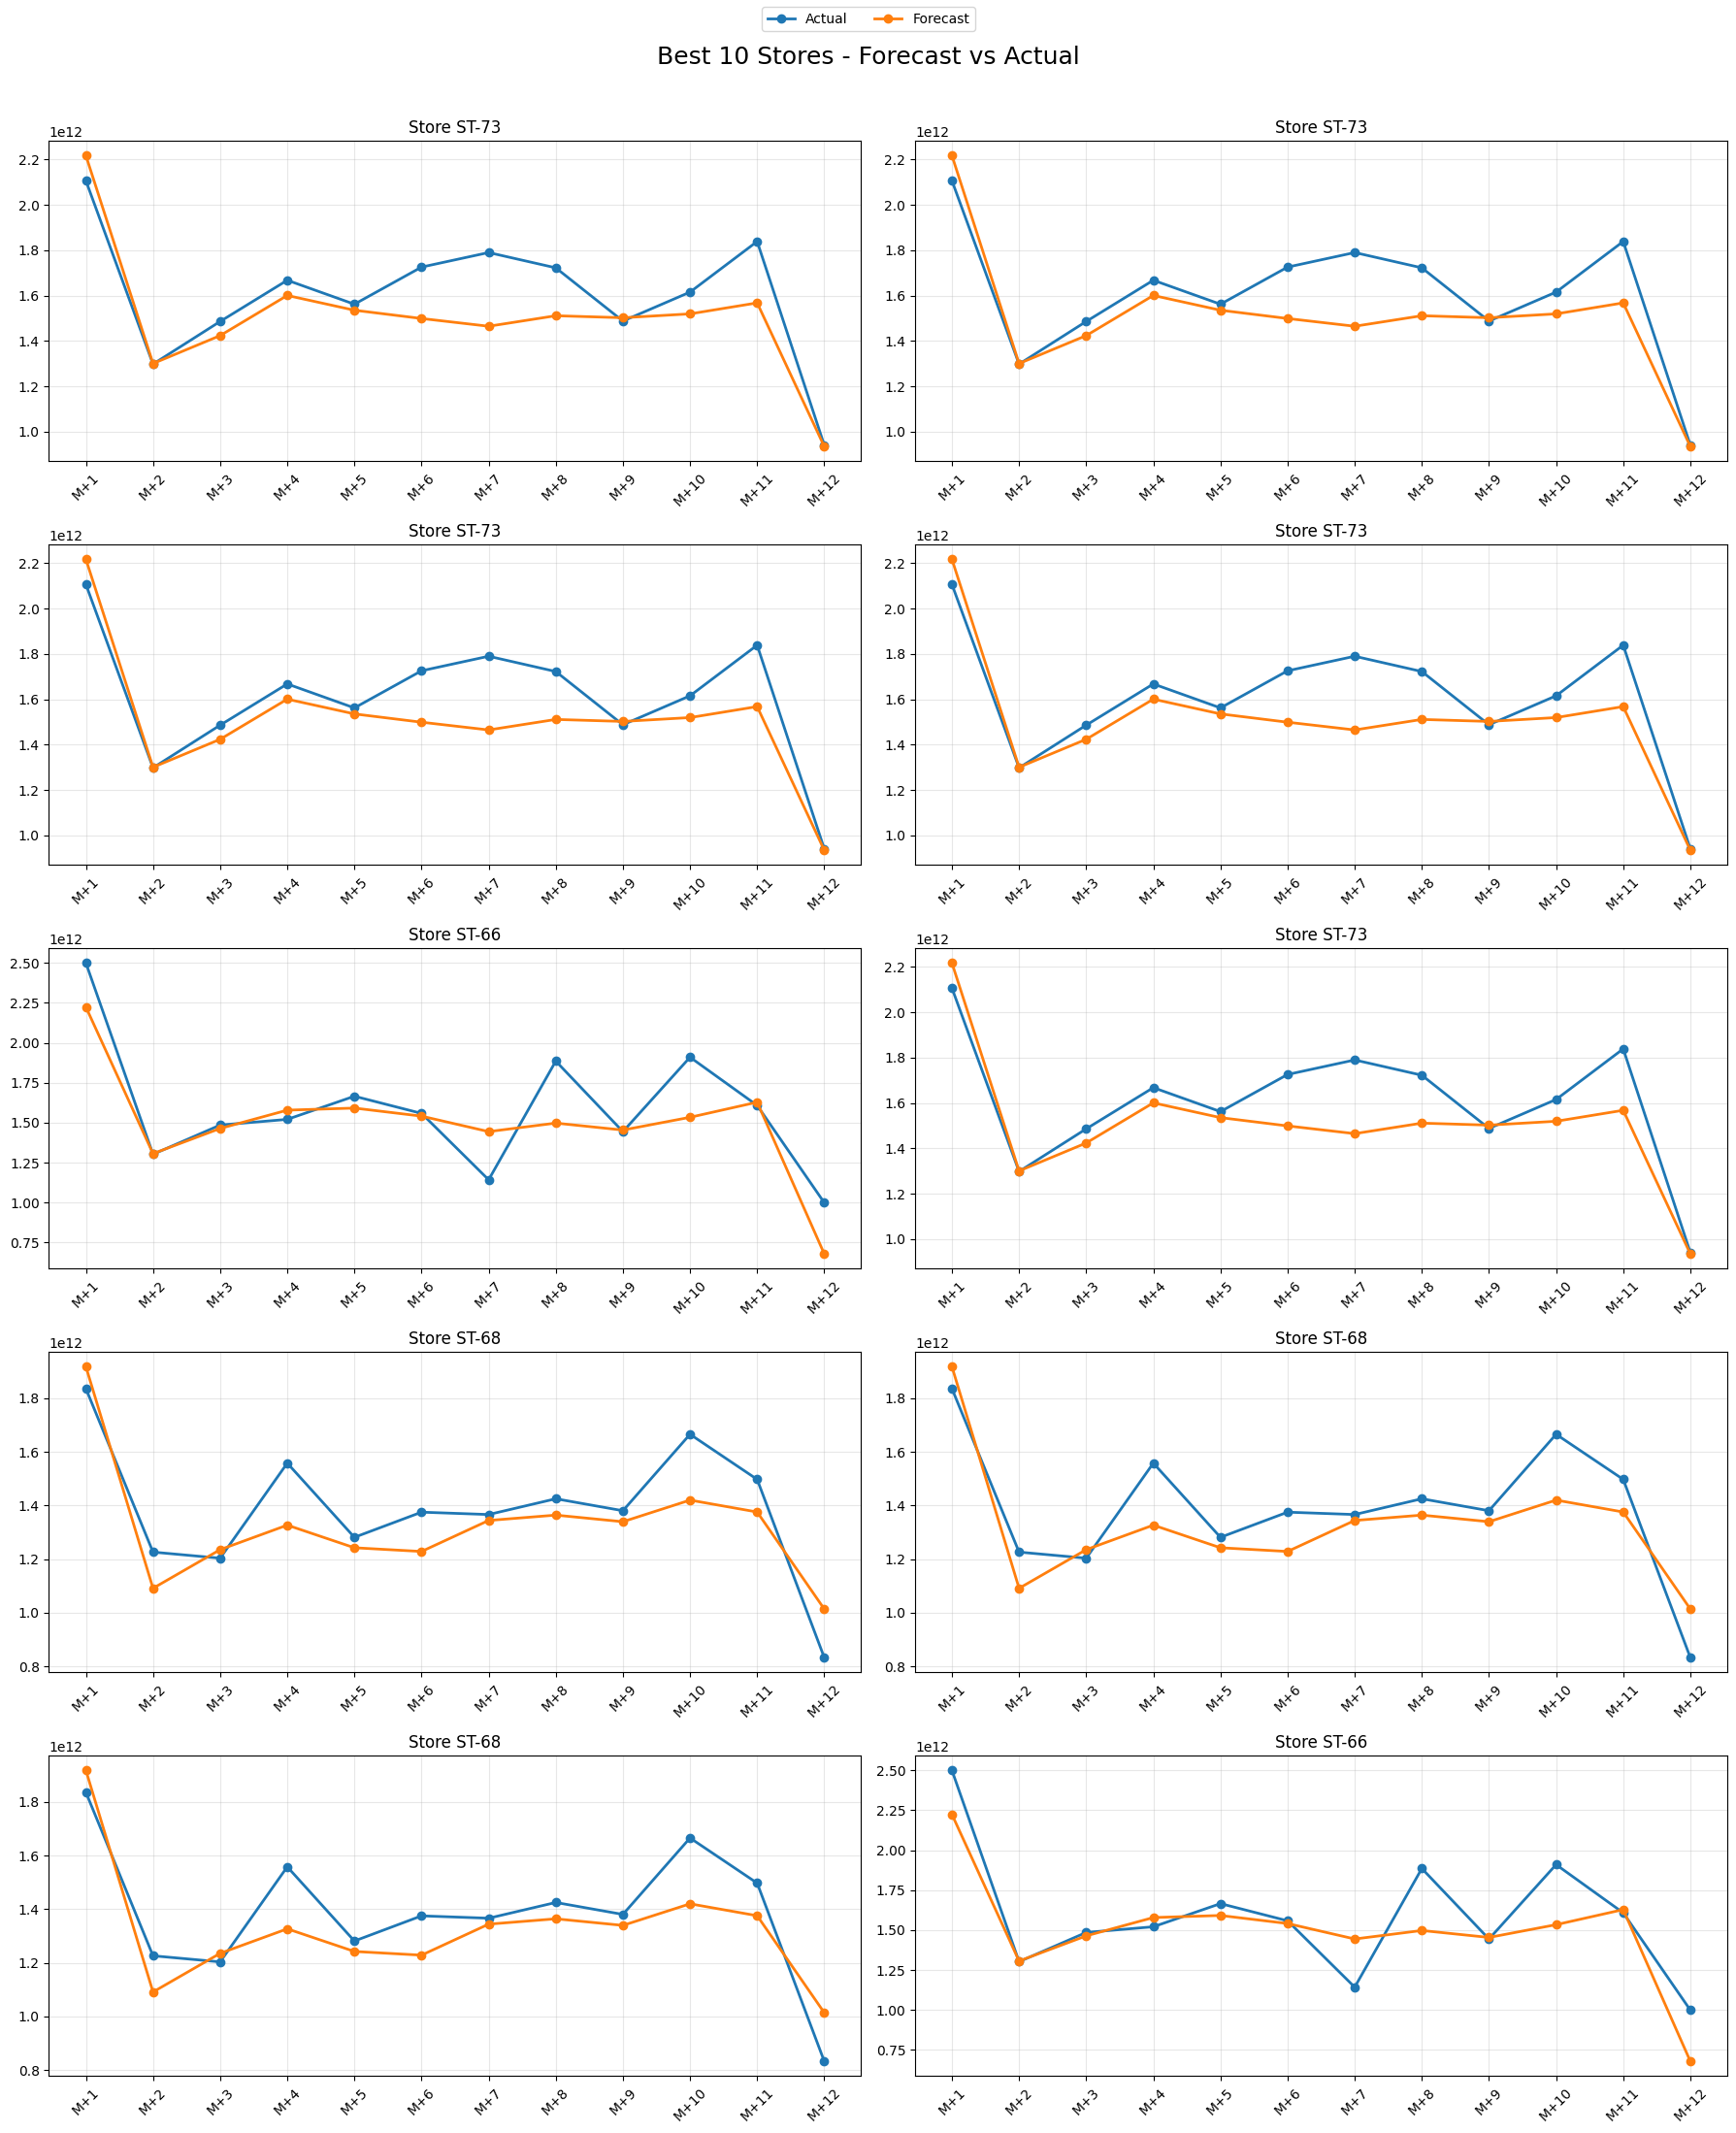

In [71]:
plot_store_group(
    worst10["store_id"].tolist(),
    "Worst 10 Stores - Forecast vs Actual"
)

plot_store_group(
    best10["store_id"].tolist(),
    "Best 10 Stores - Forecast vs Actual"
)

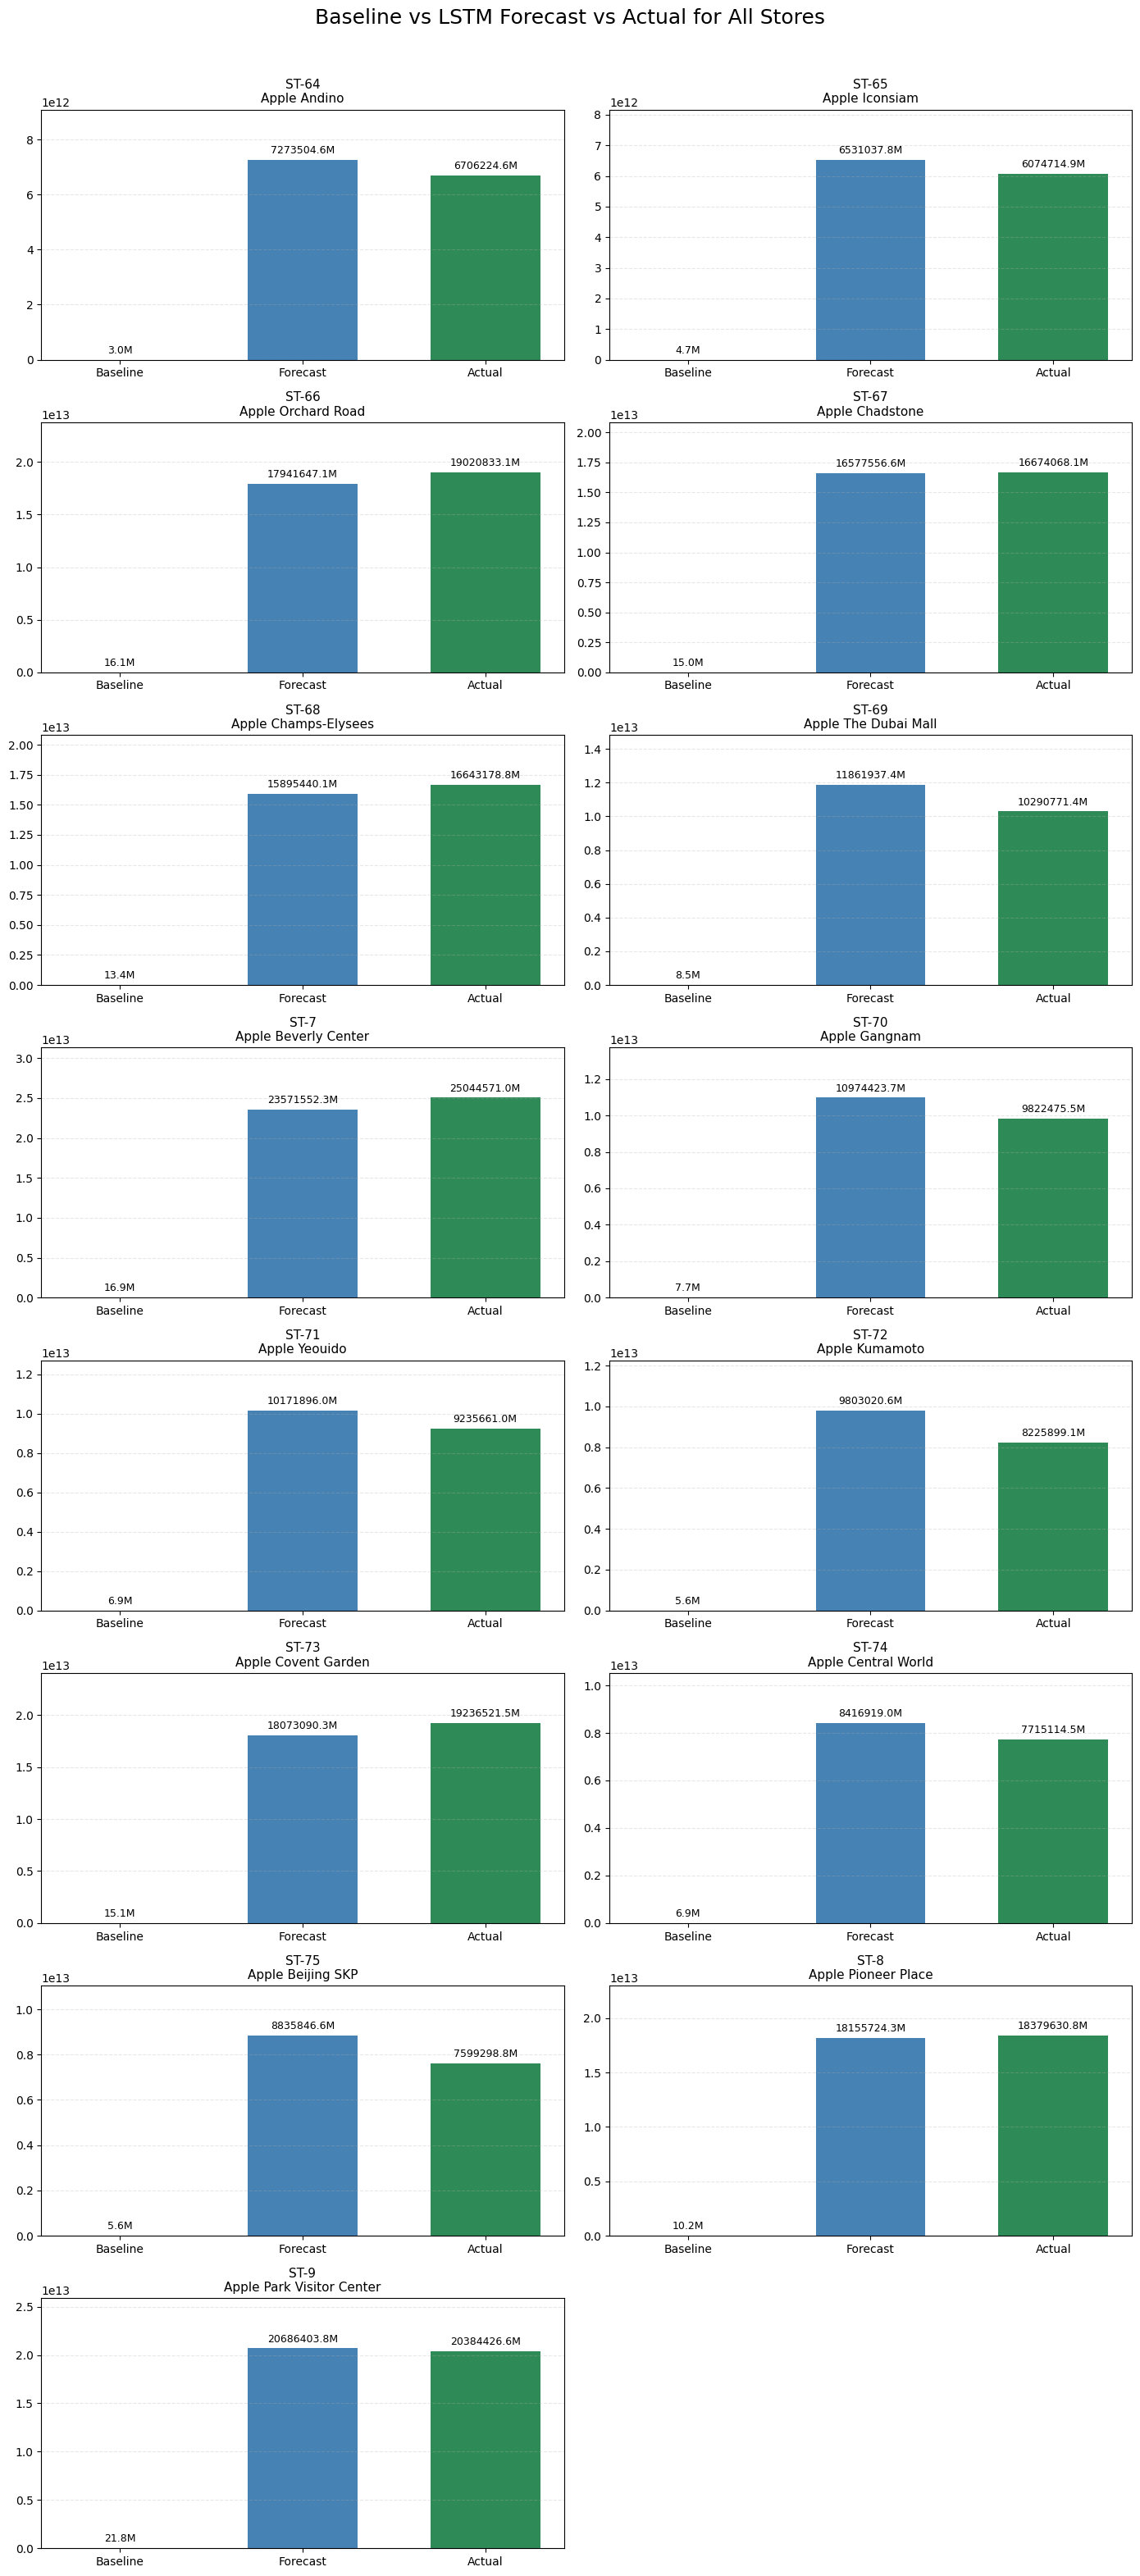

In [74]:
# More reliable plotting: explicit x positions
n_stores = len(store_results)

ncols = 2
nrows = int(np.ceil(n_stores / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, store_results.iterrows()):

    x = np.arange(3)
    values = [row["baseline"], row["forecast"], row["actual"]]

    bars = ax.bar(
        x,
        values,
        width=0.6,
        color=["gray", "steelblue", "seagreen"]
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["Baseline", "Forecast", "Actual"])

    ax.set_title(f'{row["store_id"]}\n{row["store_name"]}', fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # add labels above each bar
    ymax = max(values)

    for i, bar in enumerate(bars):
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + ymax * 0.02,
            f"{height/1e6:.1f}M",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # leave some space above bars so labels and Actual bar are visible
    ax.set_ylim(0, ymax * 1.25)

# Hide unused axes
for i in range(len(store_results), len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Baseline vs LSTM Forecast vs Actual for All Stores",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [75]:
store_results["forecast_error_pct"] = (
    np.abs(store_results["forecast"] - store_results["actual"])
    / store_results["actual"]
) * 100

store_results["baseline_error_pct"] = (
    np.abs(store_results["baseline"] - store_results["actual"])
    / store_results["actual"]
) * 100

store_results["improvement_pct"] = (
    store_results["baseline_error_pct"] -
    store_results["forecast_error_pct"]
)

In [76]:
print(
    store_results[
        [
            "store_id",
            "store_name",
            "actual",
            "forecast",
            "baseline",
            "forecast_error_pct",
            "baseline_error_pct",
            "improvement_pct"
        ]
    ]
    .sort_values("improvement_pct", ascending=False)
    .head(10)
)

   store_id                 store_name        actual      forecast  \
3     ST-67            Apple Chadstone  1.667407e+13  1.657756e+13   
13     ST-8        Apple Pioneer Place  1.837963e+13  1.815572e+13   
14     ST-9  Apple Park Visitor Center  2.038443e+13  2.068640e+13   
4     ST-68       Apple Champs-Elysees  1.664318e+13  1.589544e+13   
2     ST-66         Apple Orchard Road  1.902083e+13  1.794165e+13   
6      ST-7       Apple Beverly Center  2.504457e+13  2.357155e+13   
10    ST-73        Apple Covent Garden  1.923652e+13  1.807309e+13   
1     ST-65             Apple Iconsiam  6.074715e+12  6.531038e+12   
0     ST-64               Apple Andino  6.706225e+12  7.273505e+12   
11    ST-74        Apple Central World  7.715114e+12  8.416919e+12   

        baseline  forecast_error_pct  baseline_error_pct  improvement_pct  
3   1.498365e+07            0.578812           99.999910        99.421098  
13  1.021484e+07            1.218232           99.999944        98.781713  
1

In [77]:
# Compute percentages
store_results["forecast_error_pct"] = (
    np.abs(store_results["forecast"] - store_results["actual"])
    / store_results["actual"]
) * 100

store_results["baseline_error_pct"] = (
    np.abs(store_results["baseline"] - store_results["actual"])
    / store_results["actual"]
) * 100

store_results["improvement_pct"] = (
    store_results["baseline_error_pct"] -
    store_results["forecast_error_pct"]
)

# Convert actual / forecast / baseline into percentage of actual
store_results["forecast_vs_actual_pct"] = (
    store_results["forecast"] / store_results["actual"]
) * 100

store_results["baseline_vs_actual_pct"] = (
    store_results["baseline"] / store_results["actual"]
) * 100

# Display all stores nicely
result_table = store_results[
    [
        "store_id",
        "store_name",
        "forecast_vs_actual_pct",
        "baseline_vs_actual_pct",
        "forecast_error_pct",
        "baseline_error_pct",
        "improvement_pct"
    ]
].copy()

# Format as readable percentages
for col in [
    "forecast_vs_actual_pct",
    "baseline_vs_actual_pct",
    "forecast_error_pct",
    "baseline_error_pct",
    "improvement_pct"
]:
    result_table[col] = result_table[col].map(lambda x: f"{x:.2f}%")

# Sort by best forecast performance
result_table = result_table.sort_values("forecast_error_pct")

print(result_table.to_string(index=False))

store_id                store_name forecast_vs_actual_pct baseline_vs_actual_pct forecast_error_pct baseline_error_pct improvement_pct
   ST-67           Apple Chadstone                 99.42%                  0.00%              0.58%            100.00%          99.42%
    ST-8       Apple Pioneer Place                 98.78%                  0.00%              1.22%            100.00%          98.78%
    ST-9 Apple Park Visitor Center                101.48%                  0.00%              1.48%            100.00%          98.52%
   ST-71             Apple Yeouido                110.14%                  0.00%             10.14%            100.00%          89.86%
   ST-70             Apple Gangnam                111.73%                  0.00%             11.73%            100.00%          88.27%
   ST-69      Apple The Dubai Mall                115.27%                  0.00%             15.27%            100.00%          84.73%
   ST-75         Apple Beijing SKP                116.2

In [78]:
result_table = result_table.sort_values(
    by="forecast_error_pct",
    key=lambda s: s.str.rstrip("%").astype(float)
)

print(result_table.to_string(index=False))

store_id                store_name forecast_vs_actual_pct baseline_vs_actual_pct forecast_error_pct baseline_error_pct improvement_pct
   ST-67           Apple Chadstone                 99.42%                  0.00%              0.58%            100.00%          99.42%
    ST-8       Apple Pioneer Place                 98.78%                  0.00%              1.22%            100.00%          98.78%
    ST-9 Apple Park Visitor Center                101.48%                  0.00%              1.48%            100.00%          98.52%
   ST-68      Apple Champs-Elysees                 95.51%                  0.00%              4.49%            100.00%          95.51%
   ST-66        Apple Orchard Road                 94.33%                  0.00%              5.67%            100.00%          94.33%
    ST-7      Apple Beverly Center                 94.12%                  0.00%              5.88%            100.00%          94.12%
   ST-73       Apple Covent Garden                 93.9